# Step 1: 데이터 전처리 및 b*/t* 분리
python3.11 step1_preprocess_and_split.py

# Step 2: 정규분포 그래프 생성 (영어)
python3.11 step2_distribution_plots_en.py

# Step 3: 시계열 그래프 생성 (영어)
python3.11 step3_timeseries_plots_en.py

# Step 4: 상위 10개 베드 선정
python3.11 step4_top_beds_selection.py

#Step 1: 데이터 전처리 및 b*/t* 분리

In [ ]:
"""
Step 1: 데이터 전처리 및 b*/t* 그룹 분리
앞열(b*) vs 뒷열(t*) 양상추 구분 및 기본 통계
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260128_front_step1_features.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df = pd.read_excel(INPUT_FILE, sheet_name='원본')
print(f"전체 데이터: {len(df)}행 × {len(df.columns)}열")


데이터 로드 중...
전체 데이터: 8768행 × 29열


In [ ]:
# ============================================================================
# b*/t* 그룹 분리, 검출 성공 데이터만 필터링
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) vs 뒷열(t*) 그룹 분리")
print("=" * 80)

# lettuce_id에서 첫 글자 추출하여 그룹 구분
df['position_group'] = df['lettuce_id'].str[0]

# b 그룹 (앞열)
df_b = df[df['position_group'] == 'b'].copy()
# t 그룹 (뒷열)
df_t = df[df['position_group'] == 't'].copy()
df_b_detected = df_b[df_b['n_instances'] > 0].copy()
df_t_detected = df_t[df_t['n_instances'] > 0].copy()

print(f"\n검출 성공 데이터만 필터링:")
print(f"  - 앞열(b*): {len(df_b_detected)}행")
print(f"  - 뒷열(t*): {len(df_t_detected)}행")

# ============================================================================
# bed_date 키 정리 (시간/카메라 정보 제거)
# ============================================================================
print("\n" + "=" * 80)
print("bed_date 키 정리 중 (시간/카메라 정보 제거)...")
print("=" * 80)

def clean_bed_date(base_key_str):
    """bed00_20251204_093629_cam2 → bed00_20251204"""
    try:
        parts = base_key_str.split('_')
        return f"{parts[0]}_{parts[1]}"  # bed00_20251204
    except:
        return base_key_str

df_b_detected['bed_date_clean'] = df_b_detected['base_key'].apply(clean_bed_date)
df_t_detected['bed_date_clean'] = df_t_detected['base_key'].apply(clean_bed_date)

print(f"예시 변환:")
print(f"  원본: {df_b_detected['base_key'].iloc[0]}")
print(f"  정리: {df_b_detected['bed_date_clean'].iloc[0]}")

# ============================================================================
# 날짜 변환 (bed_date_clean에서 날짜 추출)
# ============================================================================
print("\n" + "=" * 80)
print("날짜 변환 중...")
print("=" * 80)

def extract_date(bed_date_str):
    """bed00_20251204 형식에서 날짜 추출"""
    try:
        date_part = bed_date_str.split('_')[1]  # '20251204'
        return pd.to_datetime(date_part, format='%Y%m%d')
    except:
        return pd.NaT

df_b_detected['date'] = df_b_detected['bed_date_clean'].apply(extract_date)
df_t_detected['date'] = df_t_detected['bed_date_clean'].apply(extract_date)

print(f"날짜 범위 (앞열): {df_b_detected['date'].min()} ~ {df_b_detected['date'].max()}")
print(f"날짜 범위 (뒷열): {df_t_detected['date'].min()} ~ {df_t_detected['date'].max()}")
print(f"총 기간: {(df_b_detected['date'].max() - df_b_detected['date'].min()).days + 1}일")

# ============================================================================
# px_per_mm 통합 (x, y 평균)
# ============================================================================
df_b_detected['px_per_mm'] = (df_b_detected['px_per_mm_x'] + df_b_detected['px_per_mm_y']) / 2
df_t_detected['px_per_mm'] = (df_t_detected['px_per_mm_x'] + df_t_detected['px_per_mm_y']) / 2


앞열(b*) vs 뒷열(t*) 그룹 분리

검출 성공 데이터만 필터링:
  - 앞열(b*): 3629행
  - 뒷열(t*): 3534행

bed_date 키 정리 중 (시간/카메라 정보 제거)...
예시 변환:
  원본: bed00_20251205_094145_cam2
  정리: bed00_20251205

날짜 변환 중...
날짜 범위 (앞열): 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00
날짜 범위 (뒷열): 2025-11-28 00:00:00 ~ 2025-12-26 00:00:00
총 기간: 29일


In [ ]:
# ============================================================================
# 중요 지표 14개 정의
# ============================================================================
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

print("\n" + "=" * 80)
print("중요 지표 14개 기본 통계")
print("=" * 80)

print("\n[앞열 b*]")
print(df_b_detected[IMPORTANT_FEATURES].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n[뒷열 t*]")
print(df_t_detected[IMPORTANT_FEATURES].describe().T[['mean', 'std', 'min', '50%', 'max']])

# ============================================================================
# 데이터 저장
# ============================================================================
print("\n" + "=" * 80)
print("전처리 데이터 저장 중...")
print("=" * 80)

df_b_detected.to_csv(f"{OUTPUT_DIR}/df_b_detected.csv", index=False, encoding='utf-8-sig')
df_t_detected.to_csv(f"{OUTPUT_DIR}/df_t_detected.csv", index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료:")
print(f"  - {OUTPUT_DIR}/df_b_detected.csv")
print(f"  - {OUTPUT_DIR}/df_t_detected.csv")



중요 지표 14개 기본 통계

[앞열 b*]
                        mean          std        min          50%  \
brightness_mean    86.974285    13.150360  51.214744    85.785798   
area_px          9333.866079  5234.030018  20.000000  8880.000000   
area_cm2          123.461725    75.033377   0.228842   116.357607   
px_per_mm           0.874480     0.043443   0.253227     0.873669   
front_height_cm    15.073503     6.383690   0.213936    15.364357   
area_front       9333.866079  5234.030018  20.000000  8880.000000   
aspect_ratio        0.876717     0.906604   0.188034     0.664234   
bottom_flatness     0.830046     0.186792   0.111111     0.888889   
core_prominence     0.103467     0.019760   0.100000     0.100548   
perimeter_px      468.365008   173.042864  12.242641   464.936073   
circularity         0.494433     0.115622   0.137479     0.497440   
solidity            0.897743     0.048119   0.554740     0.904406   
curvature           0.369216     0.113901   0.022806     0.359580   
roughnes

In [ ]:

# ============================================================================
# 앞열 vs 뒷열 비교 통계
# ============================================================================
# ============================================================================
# bed_date_clean 기준 그룹화 통계
# ============================================================================
print("\n" + "=" * 80)
print("bed_date_clean 기준 그룹화 통계")
print("=" * 80)

print(f"\n앞열(b*) bed_date_clean 고유값 수: {df_b_detected['bed_date_clean'].nunique()}개")
print(f"뒷열(t*) bed_date_clean 고유값 수: {df_t_detected['bed_date_clean'].nunique()}개")

print("\n상위 10개 bed_date_clean (앞열):")
print(df_b_detected['bed_date_clean'].value_counts().head(10))

print("\n상위 10개 bed_date_clean (뒷열):")
print(df_t_detected['bed_date_clean'].value_counts().head(10))


bed_date_clean 기준 그룹화 통계

앞열(b*) bed_date_clean 고유값 수: 2030개
뒷열(t*) bed_date_clean 고유값 수: 2075개

상위 10개 bed_date_clean (앞열):
bed_date_clean
bed52_20251208    3
bed06_20251215    3
bed06_20251216    3
bed52_20251209    3
bed81_20251211    3
bed81_20251209    3
bed86_20251218    3
bed86_20251217    3
bed86_20251215    3
bed83_20251213    3
Name: count, dtype: int64

상위 10개 bed_date_clean (뒷열):
bed_date_clean
bed83_20251214    3
bed29_20251223    3
bed82_20251223    3
bed38_20251221    3
bed12_20251212    3
bed35_20251213    3
bed16_20251221    3
bed33_20251218    3
bed83_20251215    3
bed80_20251217    3
Name: count, dtype: int64


In [ ]:


# ============================================================================
# 앞열 vs 뒷열 주요 지표 비교
# ============================================================================
print("\n" + "=" * 80)
print("앞열 vs 뒷열 주요 지표 비교")
print("=" * 80)

comparison = pd.DataFrame({
    '지표': IMPORTANT_FEATURES,
    '앞열_평균': [df_b_detected[f].mean() for f in IMPORTANT_FEATURES],
    '뒷열_평균': [df_t_detected[f].mean() for f in IMPORTANT_FEATURES],
    '앞열_중간값': [df_b_detected[f].median() for f in IMPORTANT_FEATURES],
    '뒷열_중간값': [df_t_detected[f].median() for f in IMPORTANT_FEATURES],
})

comparison['평균_차이(%)'] = ((comparison['뒷열_평균'] - comparison['앞열_평균']) / comparison['앞열_평균'] * 100).round(2)
comparison['중간값_차이(%)'] = ((comparison['뒷열_중간값'] - comparison['앞열_중간값']) / comparison['앞열_중간값'] * 100).round(2)

print(comparison.to_string(index=False))

comparison.to_csv(f"{OUTPUT_DIR}/comparison_b_vs_t.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 비교 통계 저장: {OUTPUT_DIR}/comparison_b_vs_t.csv")

print("\n" + "=" * 80)
print("Step 1 완료!")
print("=" * 80)



앞열 vs 뒷열 주요 지표 비교
             지표       앞열_평균       뒷열_평균      앞열_중간값      뒷열_중간값  평균_차이(%)  중간값_차이(%)
brightness_mean   86.974285  120.952063   85.785798  122.913160     39.07      43.28
        area_px 9333.866079 6360.992077 8880.000000 5691.000000    -31.85     -35.91
       area_cm2  123.461725   83.738510  116.357607   74.705492    -32.17     -35.80
      px_per_mm    0.874480    0.874935    0.873669    0.872732      0.05      -0.11
front_height_cm   15.073503   11.367388   15.364357   10.814235    -24.59     -29.61
     area_front 9333.866079 6360.992077 8880.000000 5691.000000    -31.85     -35.91
   aspect_ratio    0.876717    0.883961    0.664234    0.811727      0.83      22.20
bottom_flatness    0.830046    0.909275    0.888889    0.988371      9.55      11.19
core_prominence    0.103467    0.102073    0.100548    0.100635     -1.35       0.09
   perimeter_px  468.365008  383.122582  464.936073  371.287841    -18.20     -20.14
    circularity    0.494433    0.513516    0.4

#Step 2: 14개 중요 지표 정규분포 그래프 생성
앞열(b*) vs 뒷열(t*) 각각 3×5 다중 plot

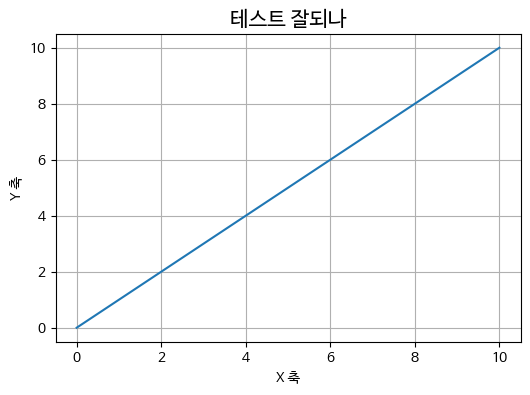

In [ ]:
# ============================================================================
# 한글 폰트 설치 및 설정
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import matplotlib

# 'Noto Sans CJK KR' 폰트 설치 (Colab 환경에 따라 다를 수 있음)
# Colab에서는 apt-get으로 폰트 설치 후 폰트 캐시를 지우고 다시 로드해야 함
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 폰트 캐시 재로드
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

# 한글 테스트 그래프 추가
x = np.linspace(0, 10, 100)
y = x

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.title("테스트 잘되나", fontsize=15)
plt.xlabel("X 축"); plt.ylabel("Y 축")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"


# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 3629행
뒷열(t*): 3534행


In [ ]:

# ============================================================================
# 중요 지표 14개
# ============================================================================
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

# 한글 라벨
FEATURE_LABELS = {
    'brightness_mean': '평균 밝기',
    'area_px': '면적 (픽셀)',
    'area_cm2': '면적 (cm²)',
    'px_per_mm': '픽셀/mm 비율',
    'front_height_cm': '정면 높이 (cm)',
    'area_front': '정면 투영 면적',
    'aspect_ratio': '장단축비',
    'bottom_flatness': '하단 평탄도',
    'core_prominence': '중심부 돌출도',
    'perimeter_px': '둘레 (픽셀)',
    'circularity': '원형도',
    'solidity': '솔리디티',
    'curvature': '곡률',
    'roughness': '거칠기'
}

# ============================================================================
# 정규분포 그래프 생성 함수
# ============================================================================
def plot_distribution(data, feature, ax, title_prefix, color):
    """단일 지표의 분포 그래프 생성"""
    # 이상치 제거 (IQR 방식)
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    filtered_data = data[(data[feature] >= lower_bound) & (data[feature] <= upper_bound)][feature]

    # 히스토그램
    n, bins, patches = ax.hist(filtered_data, bins=50, density=True,
                                alpha=0.6, color=color, edgecolor='black', linewidth=0.5)

    # 정규분포 곡선 피팅
    mu, sigma = filtered_data.mean(), filtered_data.std()
    x = np.linspace(filtered_data.min(), filtered_data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='정규분포 곡선')

    # 평균선 및 중간값선
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'평균: {mu:.2f}')
    ax.axvline(filtered_data.median(), color='blue', linestyle='--', linewidth=1.5,
               label=f'중간값: {filtered_data.median():.2f}')

    # 제목 및 라벨
    ax.set_title(f"{title_prefix} - {FEATURE_LABELS[feature]}", fontsize=10, fontweight='bold')
    ax.set_xlabel('값', fontsize=8)
    ax.set_ylabel('확률 밀도', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

    # 정규성 검정 (Shapiro-Wilk test)
    if len(filtered_data) > 3:
        _, p_value = stats.shapiro(filtered_data[:5000])  # 샘플 크기 제한
        normality = "정규분포" if p_value > 0.05 else "비정규분포"
        ax.text(0.02, 0.98, f'{normality}\n(p={p_value:.4f})',
                transform=ax.transAxes, fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# 앞열(b*) 정규분포 그래프
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) 정규분포 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('앞열(b*) 양상추 - 14개 중요 지표 분포', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_distribution(df_b, feature, axes[idx], '앞열(b*)', 'skyblue')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/distribution_b_front.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/distribution_b_front.png")
plt.close()

# ============================================================================
# 뒷열(t*) 정규분포 그래프
# ============================================================================
print("\n" + "=" * 80)
print("뒷열(t*) 정규분포 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('뒷열(t*) 양상추 - 14개 중요 지표 분포', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_distribution(df_t, feature, axes[idx], '뒷열(t*)', 'lightcoral')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/distribution_t_back.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/distribution_t_back.png")
plt.close()

# ============================================================================
# 정규성 검정 결과 요약
# ============================================================================
print("\n" + "=" * 80)
print("정규성 검정 결과 요약 (Shapiro-Wilk test)")
print("=" * 80)

normality_results = []

for feature in IMPORTANT_FEATURES:
    # 앞열
    data_b = df_b[feature].dropna()
    if len(data_b) > 3:
        _, p_b = stats.shapiro(data_b[:5000])
        norm_b = "정규" if p_b > 0.05 else "비정규"
    else:
        p_b = np.nan
        norm_b = "N/A"

    # 뒷열
    data_t = df_t[feature].dropna()
    if len(data_t) > 3:
        _, p_t = stats.shapiro(data_t[:5000])
        norm_t = "정규" if p_t > 0.05 else "비정규"
    else:
        p_t = np.nan
        norm_t = "N/A"

    normality_results.append({
        '지표': FEATURE_LABELS[feature],
        '앞열_p값': p_b,
        '앞열_판정': norm_b,
        '뒷열_p값': p_t,
        '뒷열_판정': norm_t
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

normality_df.to_csv(f"{OUTPUT_DIR}/normality_test_results.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 정규성 검정 결과 저장: {OUTPUT_DIR}/normality_test_results.csv")

print("\n" + "=" * 80)
print("Step 2 완료!")
print("=" * 80)



앞열(b*) 정규분포 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/distribution_b_front.png

뒷열(t*) 정규분포 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/distribution_t_back.png

정규성 검정 결과 요약 (Shapiro-Wilk test)
        지표        앞열_p값 앞열_판정        뒷열_p값 뒷열_판정
     평균 밝기 7.800229e-44   비정규 4.775426e-35   비정규
   면적 (픽셀) 5.712155e-23   비정규 8.102347e-41   비정규
  면적 (cm²) 2.316048e-43   비정규 2.547611e-44   비정규
  픽셀/mm 비율 3.978066e-66   비정규 1.876500e-58   비정규
정면 높이 (cm) 3.353044e-13   비정규 9.950218e-36   비정규
  정면 투영 면적 5.712155e-23   비정규 8.102347e-41   비정규
      장단축비 7.104370e-75   비정규 1.911331e-68   비정규
    하단 평탄도 1.999979e-50   비정규 8.417678e-63   비정규
   중심부 돌출도 1.386661e-84   비정규 1.316901e-85   비정규
   둘레 (픽셀) 1.912132e-08   비정규 1.205701e-29   비정규
       원형도 2.130182e-12   비정규 

#Step 3: 시계열 변화 그래프 생성
날짜를 x축으로 14개 중요 지표의 시계열 변화 시각화
bed_date_clean 기준으로 그룹화하여 평균값 계산

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step1_graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/step1_graph"

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

# 날짜 변환
df_b['date'] = pd.to_datetime(df_b['date'])
df_t['date'] = pd.to_datetime(df_t['date'])

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 3629행
뒷열(t*): 3534행


In [ ]:
# ============================================================================
# bed_date_clean 기준 그룹화 및 평균 계산
# ============================================================================
print("\n" + "=" * 80)
print("bed_date_clean 기준 그룹화 및 평균 계산 중...")
print("=" * 80)

# 앞열 그룹화
df_b_grouped = df_b.groupby(['bed_date_clean', 'date'])[IMPORTANT_FEATURES].mean().reset_index()
print(f"앞열 그룹화 결과: {len(df_b_grouped)}개 bed_date_clean")

# 뒷열 그룹화
df_t_grouped = df_t.groupby(['bed_date_clean', 'date'])[IMPORTANT_FEATURES].mean().reset_index()
print(f"뒷열 그룹화 결과: {len(df_t_grouped)}개 bed_date_clean")

# ============================================================================
# 날짜별 전체 평균 계산 (모든 베드 통합)
# ============================================================================
df_b_daily = df_b.groupby('date')[IMPORTANT_FEATURES].agg(['mean', 'std', 'count']).reset_index()
df_t_daily = df_t.groupby('date')[IMPORTANT_FEATURES].agg(['mean', 'std', 'count']).reset_index()

print(f"\n앞열 날짜별 평균: {len(df_b_daily)}일")
print(f"뒷열 날짜별 평균: {len(df_t_daily)}일")


bed_date_clean 기준 그룹화 및 평균 계산 중...
앞열 그룹화 결과: 2030개 bed_date_clean
뒷열 그룹화 결과: 2075개 bed_date_clean

앞열 날짜별 평균: 29일
뒷열 날짜별 평균: 29일


In [ ]:
# ============================================================================
# 시계열 그래프 생성 함수
# ============================================================================
def plot_timeseries(df_daily, df_grouped, feature, ax, title_prefix, color):
    """단일 지표의 시계열 그래프 생성"""

    # 날짜별 평균 (굵은 선)
    dates = df_daily['date']
    means = df_daily[(feature, 'mean')]
    stds = df_daily[(feature, 'std')]

    # 평균선
    ax.plot(dates, means, color=color, linewidth=2.5, label='전체 평균', marker='o', markersize=4)

    # 표준편차 영역
    ax.fill_between(dates, means - stds, means + stds, alpha=0.2, color=color, label='±1 표준편차')

    # 개별 bed_date_clean 추세 (얇은 선, 투명도)
    for bed_date in df_grouped['bed_date_clean'].unique()[:20]:  # 상위 20개만 표시
        bed_data = df_grouped[df_grouped['bed_date_clean'] == bed_date]
        if len(bed_data) > 1:
            ax.plot(bed_data['date'], bed_data[feature],
                   color='gray', linewidth=0.5, alpha=0.3)

    # 제목 및 라벨
    ax.set_title(f"{title_prefix} - {FEATURE_LABELS[feature]}", fontsize=10, fontweight='bold')
    ax.set_xlabel('날짜', fontsize=8)
    ax.set_ylabel('값', fontsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

    # x축 날짜 포맷
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # 통계 정보 표시
    mean_val = means.mean()
    trend = "증가" if means.iloc[-1] > means.iloc[0] else "감소"
    change_pct = ((means.iloc[-1] - means.iloc[0]) / means.iloc[0] * 100) if means.iloc[0] != 0 else 0

    ax.text(0.02, 0.98, f'평균: {mean_val:.2f}\n추세: {trend} ({change_pct:+.1f}%)',
            transform=ax.transAxes, fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ============================================================================
# 앞열(b*) 시계열 그래프
# ============================================================================
print("\n" + "=" * 80)
print("앞열(b*) 시계열 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('앞열(b*) 양상추 - 14개 중요 지표 시계열 변화', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_timeseries(df_b_daily, df_b_grouped, feature, axes[idx], '앞열(b*)', 'steelblue')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/timeseries_b_front.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/timeseries_b_front.png")
plt.close()

# ============================================================================
# 뒷열(t*) 시계열 그래프
# ============================================================================
print("\n" + "=" * 80)
print("뒷열(t*) 시계열 그래프 생성 중...")
print("=" * 80)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('뒷열(t*) 양상추 - 14개 중요 지표 시계열 변화', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, feature in enumerate(IMPORTANT_FEATURES):
    plot_timeseries(df_t_daily, df_t_grouped, feature, axes[idx], '뒷열(t*)', 'indianred')

# 마지막 빈 subplot 제거
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/timeseries_t_back.png", dpi=300, bbox_inches='tight')
print(f"✅ 저장 완료: {OUTPUT_DIR}/timeseries_t_back.png")
plt.close()

# ============================================================================
# 시계열 통계 요약
# ============================================================================
print("\n" + "=" * 80)
print("시계열 통계 요약")
print("=" * 80)

timeseries_summary = []

for feature in IMPORTANT_FEATURES:
    # 앞열
    b_means = df_b_daily[(feature, 'mean')]
    b_start = b_means.iloc[0]
    b_end = b_means.iloc[-1]
    b_change_pct = ((b_end - b_start) / b_start * 100) if b_start != 0 else 0
    b_trend = "증가" if b_end > b_start else "감소"

    # 뒷열
    t_means = df_t_daily[(feature, 'mean')]
    t_start = t_means.iloc[0]
    t_end = t_means.iloc[-1]
    t_change_pct = ((t_end - t_start) / t_start * 100) if t_start != 0 else 0
    t_trend = "증가" if t_end > t_start else "감소"

    timeseries_summary.append({
        '지표': FEATURE_LABELS[feature],
        '앞열_시작': b_start,
        '앞열_종료': b_end,
        '앞열_변화율(%)': b_change_pct,
        '앞열_추세': b_trend,
        '뒷열_시작': t_start,
        '뒷열_종료': t_end,
        '뒷열_변화율(%)': t_change_pct,
        '뒷열_추세': t_trend
    })

timeseries_df = pd.DataFrame(timeseries_summary)
print(timeseries_df.to_string(index=False))

timeseries_df.to_csv(f"{OUTPUT_DIR}/timeseries_summary.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 시계열 통계 저장: {OUTPUT_DIR}/timeseries_summary.csv")

print("\n" + "=" * 80)
print("Step 3 완료!")
print("=" * 80)



앞열(b*) 시계열 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/timeseries_b_front.png

뒷열(t*) 시계열 그래프 생성 중...
✅ 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/timeseries_t_back.png

시계열 통계 요약
        지표       앞열_시작        앞열_종료  앞열_변화율(%) 앞열_추세       뒷열_시작       뒷열_종료  뒷열_변화율(%) 뒷열_추세
     평균 밝기   95.174370    91.204654  -4.170992    감소  117.063156  105.354069 -10.002367    감소
   면적 (픽셀) 7990.588235 11691.921260  46.321158    증가 5345.316667 7420.890909  38.829771    증가
  면적 (cm²)  125.314745   145.001922  15.710184    증가   81.498382   92.339016  13.301654    증가
  픽셀/mm 비율    0.927230     0.898722  -3.074551    감소    0.948221    0.899670  -5.120222    감소
정면 높이 (cm)   13.241717    16.955101  28.043071    증가   10.414612   11.976615  14.998183    증가
  정면 투영 면적 7990.588235 11691.92126

#Step 4: 상위 10개 베드 선정
평균 및 중간값 기준으로 우수 베드 선정

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================================
# 경로 설정
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"

# ============================================================================
# 데이터 로드
# ============================================================================
print("=" * 80)
print("데이터 로드 중...")
print("=" * 80)
df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

print(f"앞열(b*): {len(df_b)}행")
print(f"뒷열(t*): {len(df_t)}행")

데이터 로드 중...
앞열(b*): 3629행
뒷열(t*): 3534행


In [ ]:
# ============================================================================
# 중요 지표 14개
# ============================================================================
# 생육 우수 판단 기준 (값이 클수록 좋은 지표)
POSITIVE_FEATURES = [
    'area_cm2',           # 면적 클수록 좋음
    'front_height_cm',    # 높이 클수록 좋음
    'solidity',           # 밀집도 높을수록 좋음
    'circularity',        # 원형도 높을수록 좋음 (결구)
    'bottom_flatness'     # 평탄도 높을수록 좋음
]

# ============================================================================
# bed_date_clean 기준 그룹화 및 통계 계산
# ============================================================================
print("\n" + "=" * 80)
print("bed_date_clean 기준 그룹화 및 통계 계산 중...")
print("=" * 80)

def calculate_bed_stats(df, group_name):
    """베드별 통계 계산"""

    # bed_date_clean 기준 그룹화
    grouped = df.groupby('bed_date_clean')[IMPORTANT_FEATURES].agg(['mean', 'median', 'std', 'count']).reset_index()

    # 컬럼명 단순화
    grouped.columns = ['bed_date_clean'] + [f"{feat}_{stat}" for feat in IMPORTANT_FEATURES for stat in ['mean', 'median', 'std', 'count']]

    # 샘플 수 필터링 (최소 2개 이상)
    grouped = grouped[grouped['brightness_mean_count'] >= 2].copy()

    print(f"\n{group_name} 통계:")
    print(f"  - 총 bed_date_clean 수: {len(grouped)}개")
    print(f"  - 평균 샘플 수: {grouped['brightness_mean_count'].mean():.1f}개")

    return grouped

# 앞열 통계
df_b_stats = calculate_bed_stats(df_b, "앞열(b*)")

# 뒷열 통계
df_t_stats = calculate_bed_stats(df_t, "뒷열(t*)")

# ============================================================================
# 종합 점수 계산 (생육 우수도)
# ============================================================================
print("\n" + "=" * 80)
print("종합 점수 계산 중...")
print("=" * 80)

def calculate_composite_score(df_stats, features):
    """종합 점수 계산 (Z-score 정규화 후 합산)"""

    scores = pd.DataFrame()
    scores['bed_date_clean'] = df_stats['bed_date_clean']

    # 평균 기준 Z-score
    mean_scores = []
    for feat in features:
        col = f"{feat}_mean"
        if col in df_stats.columns:
            z_score = (df_stats[col] - df_stats[col].mean()) / df_stats[col].std()
            mean_scores.append(z_score)

    scores['mean_score'] = pd.concat(mean_scores, axis=1).mean(axis=1)

    # 중간값 기준 Z-score
    median_scores = []
    for feat in features:
        col = f"{feat}_median"
        if col in df_stats.columns:
            z_score = (df_stats[col] - df_stats[col].mean()) / df_stats[col].std()
            median_scores.append(z_score)

    scores['median_score'] = pd.concat(median_scores, axis=1).mean(axis=1)

    # 종합 점수 (평균과 중간값의 평균)
    scores['composite_score'] = (scores['mean_score'] + scores['median_score']) / 2

    # 원본 데이터 병합
    scores = scores.merge(df_stats, on='bed_date_clean')

    return scores

# 앞열 점수 계산
df_b_scores = calculate_composite_score(df_b_stats, POSITIVE_FEATURES)
print(f"앞열 점수 계산 완료: {len(df_b_scores)}개 베드")

# 뒷열 점수 계산
df_t_scores = calculate_composite_score(df_t_stats, POSITIVE_FEATURES)
print(f"뒷열 점수 계산 완료: {len(df_t_scores)}개 베드")

# ============================================================================
# 상위 10개 베드 선정
# ============================================================================
print("\n" + "=" * 80)
print("상위 10개 베드 선정 (종합 점수 기준)")
print("=" * 80)

# 앞열 상위 10개
top10_b = df_b_scores.nlargest(10, 'composite_score')
print("\n[앞열(b*) 상위 10개 베드]")
print(top10_b[['bed_date_clean', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
              'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# 뒷열 상위 10개
top10_t = df_t_scores.nlargest(10, 'composite_score')
print("\n[뒷열(t*) 상위 10개 베드]")
print(top10_t[['bed_date_clean', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
              'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# ============================================================================
# 하위 10개 베드 선정 (비교용)
# ============================================================================
print("\n" + "=" * 80)
print("하위 10개 베드 선정 (종합 점수 기준)")
print("=" * 80)

# 앞열 하위 10개
bottom10_b = df_b_scores.nsmallest(10, 'composite_score')
print("\n[앞열(b*) 하위 10개 베드]")
print(bottom10_b[['bed_date_clean', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
                 'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# 뒷열 하위 10개
bottom10_t = df_t_scores.nsmallest(10, 'composite_score')
print("\n[뒷열(t*) 하위 10개 베드]")
print(bottom10_t[['bed_date_clean', 'composite_score', 'area_cm2_mean', 'front_height_cm_mean',
                 'circularity_mean', 'solidity_mean', 'brightness_mean_count']].to_string(index=False))

# ============================================================================
# 결과 저장
# ============================================================================
print("\n" + "=" * 80)
print("결과 저장 중...")
print("=" * 80)

# 전체 점수 저장
df_b_scores.to_csv(f"{OUTPUT_DIR}/bed_scores_b_front.csv", index=False, encoding='utf-8-sig')
df_t_scores.to_csv(f"{OUTPUT_DIR}/bed_scores_t_back.csv", index=False, encoding='utf-8-sig')
print(f"✅ 전체 베드 점수 저장:")
print(f"  - {OUTPUT_DIR}/bed_scores_b_front.csv")
print(f"  - {OUTPUT_DIR}/bed_scores_t_back.csv")

# 상위 10개 저장
top10_b.to_csv(f"{OUTPUT_DIR}/top10_beds_b_front.csv", index=False, encoding='utf-8-sig')
top10_t.to_csv(f"{OUTPUT_DIR}/top10_beds_t_back.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 상위 10개 베드 저장:")
print(f"  - {OUTPUT_DIR}/top10_beds_b_front.csv")
print(f"  - {OUTPUT_DIR}/top10_beds_t_back.csv")

# 하위 10개 저장
bottom10_b.to_csv(f"{OUTPUT_DIR}/bottom10_beds_b_front.csv", index=False, encoding='utf-8-sig')
bottom10_t.to_csv(f"{OUTPUT_DIR}/bottom10_beds_t_back.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 하위 10개 베드 저장:")
print(f"  - {OUTPUT_DIR}/bottom10_beds_b_front.csv")
print(f"  - {OUTPUT_DIR}/bottom10_beds_t_back.csv")

# ============================================================================
# 상위 vs 하위 비교 통계
# ============================================================================
print("\n" + "=" * 80)
print("상위 vs 하위 베드 비교 통계")
print("=" * 80)

comparison_stats = []

for feat in POSITIVE_FEATURES:
    mean_col = f"{feat}_mean"

    # 앞열
    b_top_mean = top10_b[mean_col].mean()
    b_bottom_mean = bottom10_b[mean_col].mean()
    b_diff_pct = ((b_top_mean - b_bottom_mean) / b_bottom_mean * 100) if b_bottom_mean != 0 else 0

    # 뒷열
    t_top_mean = top10_t[mean_col].mean()
    t_bottom_mean = bottom10_t[mean_col].mean()
    t_diff_pct = ((t_top_mean - t_bottom_mean) / t_bottom_mean * 100) if t_bottom_mean != 0 else 0

    comparison_stats.append({
        '지표': feat,
        '앞열_상위평균': b_top_mean,
        '앞열_하위평균': b_bottom_mean,
        '앞열_차이(%)': b_diff_pct,
        '뒷열_상위평균': t_top_mean,
        '뒷열_하위평균': t_bottom_mean,
        '뒷열_차이(%)': t_diff_pct
    })

comparison_df = pd.DataFrame(comparison_stats)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(f"{OUTPUT_DIR}/top_vs_bottom_comparison.csv", index=False, encoding='utf-8-sig')
print(f"\n✅ 비교 통계 저장: {OUTPUT_DIR}/top_vs_bottom_comparison.csv")

print("\n" + "=" * 80)
print("Step 4 완료!")
print("=" * 80)



bed_date_clean 기준 그룹화 및 통계 계산 중...

앞열(b*) 통계:
  - 총 bed_date_clean 수: 1435개
  - 평균 샘플 수: 2.1개

뒷열(t*) 통계:
  - 총 bed_date_clean 수: 1435개
  - 평균 샘플 수: 2.0개

종합 점수 계산 중...
앞열 점수 계산 완료: 1435개 베드
뒷열 점수 계산 완료: 1435개 베드

상위 10개 베드 선정 (종합 점수 기준)

[앞열(b*) 상위 10개 베드]
bed_date_clean  composite_score  area_cm2_mean  front_height_cm_mean  circularity_mean  solidity_mean  brightness_mean_count
bed54_20251129         4.345098    1039.552160             41.662272          0.554780       0.905354                      2
bed38_20251223         1.987335     286.294043             24.833499          0.674206       0.969850                      2
bed85_20251215         1.594859     246.908884             20.629653          0.670646       0.951635                      2
bed19_20251223         1.484867     295.356036             27.177256          0.531132       0.928904                      3
bed77_20251218         1.432165     255.821315             23.813876          0.543923       0.941593              

# 시계열 데이터 이상 이유

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================
INPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("INVESTIGATION: Time Series Stagnation Issue")
print("=" * 80)

df_b = pd.read_csv(f"{INPUT_DIR}/df_b_detected.csv")
df_t = pd.read_csv(f"{INPUT_DIR}/df_t_detected.csv")

df_b['date'] = pd.to_datetime(df_b['date'])
df_t['date'] = pd.to_datetime(df_t['date'])

print(f"\nFront row (b*): {len(df_b)} samples")
print(f"Back row (t*): {len(df_t)} samples")

INVESTIGATION: Time Series Stagnation Issue

Front row (b*): 3629 samples
Back row (t*): 3534 samples


In [ ]:


# ============================================================================
# INVESTIGATION 1: Daily Sample Composition
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 1: Daily Sample Composition")
print("=" * 80)

def analyze_daily_composition(df, group_name):
    """Analyze which beds are sampled each day"""

    daily_stats = []

    for date in sorted(df['date'].unique()):
        day_data = df[df['date'] == date]

        # Extract bed number
        day_data['bed_num'] = day_data['bed_date_clean'].str.extract(r'(bed\d+)')[0]

        unique_beds = day_data['bed_num'].nunique()
        total_samples = len(day_data)
        avg_area = day_data['area_cm2'].mean()
        std_area = day_data['area_cm2'].std()

        # Check for outliers (3 sigma rule)
        Q1 = day_data['area_cm2'].quantile(0.25)
        Q3 = day_data['area_cm2'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = len(day_data[(day_data['area_cm2'] < Q1 - 3*IQR) |
                                 (day_data['area_cm2'] > Q3 + 3*IQR)])

        daily_stats.append({
            'date': date,
            'unique_beds': unique_beds,
            'total_samples': total_samples,
            'avg_area_cm2': avg_area,
            'std_area_cm2': std_area,
            'cv_area': (std_area / avg_area * 100) if avg_area > 0 else 0,
            'outliers': outliers,
            'outlier_ratio': (outliers / total_samples * 100) if total_samples > 0 else 0
        })

    daily_df = pd.DataFrame(daily_stats)

    print(f"\n{group_name} Daily Composition:")
    print(daily_df.to_string(index=False))

    return daily_df

daily_b = analyze_daily_composition(df_b, "Front row (b*)")
daily_t = analyze_daily_composition(df_t, "Back row (t*)")

# Save daily composition
daily_b.to_csv(f"{OUTPUT_DIR}/daily_composition_b.csv", index=False, encoding='utf-8-sig')
daily_t.to_csv(f"{OUTPUT_DIR}/daily_composition_t.csv", index=False, encoding='utf-8-sig')



INVESTIGATION 1: Daily Sample Composition


/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date_clean'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date_clean'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th


Front row (b*) Daily Composition:
      date  unique_beds  total_samples  avg_area_cm2  std_area_cm2    cv_area  outliers  outlier_ratio
2025-11-28           41             51    125.314745    154.932337 123.634563         4       7.843137
2025-11-29           50             66    112.354051    191.139266 170.122273         4       6.060606
2025-11-30           70            101     72.865377     43.620683  59.864760         0       0.000000
2025-12-01           59             87     78.587654     41.688580  53.047239         0       0.000000
2025-12-02           73            107     92.410012     42.211875  45.678897         0       0.000000
2025-12-03           81            123    101.200385     51.760364  51.146410         0       0.000000
2025-12-04           91            153    121.129533     60.890157  50.268630         0       0.000000
2025-12-05           87            147    106.393418     49.833150  46.838564         0       0.000000
2025-12-06           82            140

/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date_clean'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['bed_num'] = day_data['bed_date_clean'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1140567045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th


Back row (t*) Daily Composition:
      date  unique_beds  total_samples  avg_area_cm2  std_area_cm2    cv_area  outliers  outlier_ratio
2025-11-28           51             60     81.498382    104.359407 128.050893         4       6.666667
2025-11-29           54             78     61.955740     32.113312  51.832666         0       0.000000
2025-11-30           86            125     70.744150     32.427238  45.837342         0       0.000000
2025-12-01           62             96     69.773581     31.485305  45.124967         0       0.000000
2025-12-02           75            120     67.290229     31.727901  47.150830         0       0.000000
2025-12-03           84            142     76.076059     29.491856  38.766278         0       0.000000
2025-12-04           93            161     81.470807     33.593216  41.233439         0       0.000000
2025-12-05           91            164     79.160108     33.396612  42.188690         0       0.000000
2025-12-06           88            158 

In [ ]:
# ============================================================================
# INVESTIGATION 2: Outlier Analysis (12/26 and others)
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 2: Outlier Analysis")
print("=" * 80)

def analyze_outliers(df, group_name):
    """Analyze outliers by date"""

    print(f"\n{group_name} Outlier Analysis:")

    # Overall statistics
    overall_mean = df['area_cm2'].mean()
    overall_std = df['area_cm2'].std()

    print(f"Overall mean area: {overall_mean:.2f} cm²")
    print(f"Overall std area: {overall_std:.2f} cm²")

    # Find extreme outliers (> 3 sigma)
    outliers = df[(df['area_cm2'] > overall_mean + 3*overall_std) |
                  (df['area_cm2'] < overall_mean - 3*overall_std)]

    print(f"\nExtreme outliers (>3σ): {len(outliers)} samples ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        print("\nTop 10 largest outliers:")
        top_outliers = outliers.nlargest(10, 'area_cm2')[['date', 'bed_date_clean', 'area_cm2', 'front_height_cm']]
        print(top_outliers.to_string(index=False))

        # Outliers by date
        outlier_by_date = outliers.groupby('date').size().reset_index(name='count')
        outlier_by_date = outlier_by_date.sort_values('count', ascending=False)

        print("\nOutliers by date (top 5):")
        print(outlier_by_date.head().to_string(index=False))

    return outliers

outliers_b = analyze_outliers(df_b, "Front row (b*)")
outliers_t = analyze_outliers(df_t, "Back row (t*)")


INVESTIGATION 2: Outlier Analysis

Front row (b*) Outlier Analysis:
Overall mean area: 123.46 cm²
Overall std area: 75.03 cm²

Extreme outliers (>3σ): 19 samples (0.52%)

Top 10 largest outliers:
      date bed_date_clean    area_cm2  front_height_cm
2025-11-29 bed54_20251129 1343.651577        48.967978
2025-11-28 bed46_20251128  977.650650        46.385472
2025-11-29 bed54_20251129  735.452744        34.356565
2025-11-29 bed46_20251129  555.055942        26.453986
2025-11-28 bed87_20251128  550.148591        22.608304
2025-12-22 bed85_20251222  436.541838        26.636790
2025-11-28 bed28_20251128  416.568757        27.527365
2025-12-22 bed59_20251222  404.830921        28.574405
2025-11-28 bed25_20251128  404.071277        24.816815
2025-12-19 bed80_20251219  394.435668        28.916598

Outliers by date (top 5):
      date  count
2025-11-28      4
2025-11-29      4
2025-12-17      2
2025-12-22      2
2025-12-11      1

Back row (t*) Outlier Analysis:
Overall mean area: 83.74 cm²
O

In [ ]:
# ============================================================================
# INVESTIGATION 3: Bed Rotation Pattern
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 3: Bed Rotation Pattern")
print("=" * 80)

def analyze_bed_rotation(df, group_name):
    """Analyze which beds appear on which dates"""

    # Extract bed number
    df['bed_num'] = df['bed_date_clean'].str.extract(r'(bed\d+)')[0]

    # Count appearances per bed
    bed_counts = df.groupby('bed_num')['date'].nunique().reset_index()
    bed_counts.columns = ['bed_num', 'days_appeared']
    bed_counts = bed_counts.sort_values('days_appeared', ascending=False)

    print(f"\n{group_name} Bed Rotation Pattern:")
    print(f"Total unique beds: {len(bed_counts)}")
    print(f"Beds appearing all days ({df['date'].nunique()}): {len(bed_counts[bed_counts['days_appeared'] == df['date'].nunique()])}")
    print(f"Beds appearing only once: {len(bed_counts[bed_counts['days_appeared'] == 1])}")

    print("\nTop 10 most frequently appearing beds:")
    print(bed_counts.head(10).to_string(index=False))

    print("\nBottom 10 least frequently appearing beds:")
    print(bed_counts.tail(10).to_string(index=False))

    # Check if same beds are measured consistently
    bed_date_matrix = df.groupby(['bed_num', 'date']).size().unstack(fill_value=0)

    print(f"\nBed-Date Matrix shape: {bed_date_matrix.shape[0]} beds × {bed_date_matrix.shape[1]} dates")

    return bed_counts, bed_date_matrix

bed_counts_b, bed_matrix_b = analyze_bed_rotation(df_b, "Front row (b*)")
bed_counts_t, bed_matrix_t = analyze_bed_rotation(df_t, "Back row (t*)")


INVESTIGATION 3: Bed Rotation Pattern

Front row (b*) Bed Rotation Pattern:
Total unique beds: 96
Beds appearing all days (29): 0
Beds appearing only once: 0

Top 10 most frequently appearing beds:
bed_num  days_appeared
  bed03             27
  bed15             27
  bed38             27
  bed75             27
  bed51             27
  bed42             27
  bed35             27
  bed08             26
  bed28             26
  bed86             26

Bottom 10 least frequently appearing beds:
bed_num  days_appeared
  bed70             12
  bed14             12
  bed31             10
  bed66              9
  bed87              8
  bed40              7
  bed53              6
  bed48              6
  bed89              6
  bed32              4

Bed-Date Matrix shape: 96 beds × 29 dates

Back row (t*) Bed Rotation Pattern:
Total unique beds: 96
Beds appearing all days (29): 0
Beds appearing only once: 0

Top 10 most frequently appearing beds:
bed_num  days_appeared
  bed02             28
  b

In [ ]:
# ============================================================================
# INVESTIGATION 4: Detection Failure Pattern
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 4: Detection Failure Pattern")
print("=" * 80)

# Load original data (including failed detections)
df_all = pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260128_front_step1_features.xlsx", sheet_name='원본')
df_all['position_group'] = df_all['lettuce_id'].str[0]

df_all_b = df_all[df_all['position_group'] == 'b'].copy()
df_all_t = df_all[df_all['position_group'] == 't'].copy()

def clean_bed_date(base_key_str):
    try:
        parts = base_key_str.split('_')
        return f"{parts[0]}_{parts[1]}"
    except:
        return base_key_str

def extract_date(bed_date_str):
    try:
        date_part = bed_date_str.split('_')[1]
        return pd.to_datetime(date_part, format='%Y%m%d')
    except:
        return pd.NaT

df_all_b['bed_date_clean'] = df_all_b['base_key'].apply(clean_bed_date)
df_all_b['date'] = df_all_b['bed_date_clean'].apply(extract_date)

df_all_t['bed_date_clean'] = df_all_t['base_key'].apply(clean_bed_date)
df_all_t['date'] = df_all_t['bed_date_clean'].apply(extract_date)

def analyze_detection_failure(df_all, df_detected, group_name):
    """Analyze detection failure patterns"""

    print(f"\n{group_name} Detection Failure Analysis:")

    total_images = len(df_all)
    detected_images = len(df_detected)
    failed_images = total_images - detected_images

    print(f"Total images: {total_images}")
    print(f"Detected: {detected_images} ({detected_images/total_images*100:.1f}%)")
    print(f"Failed: {failed_images} ({failed_images/total_images*100:.1f}%)")

    # Failure by date
    df_all['detected'] = df_all['n_instances'] > 0
    failure_by_date = df_all.groupby('date')['detected'].agg(['sum', 'count']).reset_index()
    failure_by_date['failure_rate'] = (1 - failure_by_date['sum'] / failure_by_date['count']) * 100
    failure_by_date = failure_by_date.sort_values('failure_rate', ascending=False)

    print("\nDetection failure rate by date (top 5):")
    print(failure_by_date.head()[['date', 'sum', 'count', 'failure_rate']].to_string(index=False))

    return failure_by_date

failure_b = analyze_detection_failure(df_all_b, df_b, "Front row (b*)")
failure_t = analyze_detection_failure(df_all_t, df_t, "Back row (t*)")



INVESTIGATION 4: Detection Failure Pattern

Front row (b*) Detection Failure Analysis:
Total images: 4595
Detected: 3629 (79.0%)
Failed: 966 (21.0%)

Detection failure rate by date (top 5):
      date  sum  count  failure_rate
2025-11-28   51    173     70.520231
2025-12-25    1      3     66.666667
2025-11-29   66    135     51.111111
2025-11-30  101    199     49.246231
2025-12-01   87    145     40.000000

Back row (t*) Detection Failure Analysis:
Total images: 4173
Detected: 3534 (84.7%)
Failed: 639 (15.3%)

Detection failure rate by date (top 5):
      date  sum  count  failure_rate
2025-11-28   60    163     63.190184
2025-11-29   78    129     39.534884
2025-11-30  125    181     30.939227
2025-12-01   96    139     30.935252
2025-12-02  120    168     28.571429


In [ ]:

# ============================================================================
# INVESTIGATION 5: Individual Bed Tracking
# ============================================================================
print("\n" + "=" * 80)
print("INVESTIGATION 5: Individual Bed Tracking (Sample)")
print("=" * 80)

def track_individual_beds(df, group_name, top_n=5):
    """Track individual beds over time"""

    df['bed_num'] = df['bed_date_clean'].str.extract(r'(bed\d+)')[0]

    # Select beds that appear most frequently
    bed_counts = df.groupby('bed_num')['date'].nunique()
    top_beds = bed_counts.nlargest(top_n).index.tolist()

    print(f"\n{group_name} Individual Bed Tracking (Top {top_n} beds):")

    for bed in top_beds:
        bed_data = df[df['bed_num'] == bed].sort_values('date')

        if len(bed_data) > 1:
            start_area = bed_data['area_cm2'].iloc[0]
            end_area = bed_data['area_cm2'].iloc[-1]
            change = end_area - start_area
            change_pct = (change / start_area * 100) if start_area > 0 else 0

            print(f"\n{bed}: {len(bed_data)} measurements")
            print(f"  Start: {start_area:.2f} cm² → End: {end_area:.2f} cm²")
            print(f"  Change: {change:+.2f} cm² ({change_pct:+.1f}%)")
            print(f"  Date range: {bed_data['date'].min().strftime('%Y-%m-%d')} to {bed_data['date'].max().strftime('%Y-%m-%d')}")

track_individual_beds(df_b, "Front row (b*)")
track_individual_beds(df_t, "Back row (t*)")



INVESTIGATION 5: Individual Bed Tracking (Sample)

Front row (b*) Individual Bed Tracking (Top 5 beds):

bed03: 48 measurements
  Start: 168.25 cm² → End: 163.06 cm²
  Change: -5.18 cm² (-3.1%)
  Date range: 2025-11-28 to 2025-12-26

bed15: 50 measurements
  Start: 70.48 cm² → End: 271.12 cm²
  Change: +200.65 cm² (+284.7%)
  Date range: 2025-11-28 to 2025-12-26

bed35: 49 measurements
  Start: 91.93 cm² → End: 312.88 cm²
  Change: +220.94 cm² (+240.3%)
  Date range: 2025-11-28 to 2025-12-26

bed38: 47 measurements
  Start: 100.75 cm² → End: 22.56 cm²
  Change: -78.19 cm² (-77.6%)
  Date range: 2025-11-29 to 2025-12-26

bed42: 48 measurements
  Start: 50.39 cm² → End: 129.28 cm²
  Change: +78.89 cm² (+156.5%)
  Date range: 2025-11-28 to 2025-12-26

Back row (t*) Individual Bed Tracking (Top 5 beds):

bed02: 46 measurements
  Start: 66.12 cm² → End: 152.73 cm²
  Change: +86.61 cm² (+131.0%)
  Date range: 2025-11-28 to 2025-12-26

bed12: 48 measurements
  Start: 33.53 cm² → End: 48.13 c

In [ ]:

# ============================================================================
# Summary and Conclusions
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY OF FINDINGS")
print("=" * 80)

print("\n1. Daily Sample Composition:")
print(f"   - Front row: {daily_b['unique_beds'].mean():.1f} unique beds per day (avg)")
print(f"   - Back row: {daily_t['unique_beds'].mean():.1f} unique beds per day (avg)")
print(f"   - Coefficient of variation: Front {daily_b['cv_area'].mean():.1f}%, Back {daily_t['cv_area'].mean():.1f}%")

print("\n2. Outlier Impact:")
print(f"   - Front row outliers: {len(outliers_b)} ({len(outliers_b)/len(df_b)*100:.2f}%)")
print(f"   - Back row outliers: {len(outliers_t)} ({len(outliers_t)/len(df_t)*100:.2f}%)")

print("\n3. Bed Rotation:")
print(f"   - Front row: {len(bed_counts_b)} unique beds")
print(f"   - Back row: {len(bed_counts_t)} unique beds")
print(f"   - Not all beds appear every day → sample composition changes daily")

print("\n4. Detection Failure:")
print(f"   - Front row: {len(df_all_b) - len(df_b)} failed ({(len(df_all_b) - len(df_b))/len(df_all_b)*100:.1f}%)")
print(f"   - Back row: {len(df_all_t) - len(df_t)} failed ({(len(df_all_t) - len(df_t))/len(df_all_t)*100:.1f}%)")

print("\n" + "=" * 80)
print("INVESTIGATION COMPLETED")
print("=" * 80)



SUMMARY OF FINDINGS

1. Daily Sample Composition:
   - Front row: 70.0 unique beds per day (avg)
   - Back row: 71.6 unique beds per day (avg)
   - Coefficient of variation: Front 59.9%, Back 53.9%

2. Outlier Impact:
   - Front row outliers: 19 (0.52%)
   - Back row outliers: 50 (1.41%)

3. Bed Rotation:
   - Front row: 96 unique beds
   - Back row: 96 unique beds
   - Not all beds appear every day → sample composition changes daily

4. Detection Failure:
   - Front row: 966 failed (21.0%)
   - Back row: 639 failed (15.3%)

INVESTIGATION COMPLETED


#평균값 산출하기

In [ ]:
import pandas as pd
import re
import numpy as np
from pathlib import Path

# =========================================================
# 베드-날짜(bed_date) 기준 통계 산출 (다변수 + CV 포함)
# - groupby: bed_date
# - 대상 변수: area_cm2, conf, brightness_mean, blur_score,
#            perimeter_px, circularity, solidity, concavity, curvature, roughness
# - 통계: mean, std, min, max, cv(std/mean)
# - 결과: 컬럼을 모두 펼쳐서(변수_통계) 엑셀로 저장
# =========================================================

# ====== 0) 입력/출력 경로 ======
# (1) 사용자가 준 엑셀(원본 시트) 기준으로 진행
in_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260128_front_step1_features.xlsx"
sheet_name = "원본"

out_path = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260130_lettuce index_statical.xlsx"

# 출력 디렉토리 생성
Path(out_path).parent.mkdir(parents=True, exist_ok=True)

# 선택: cam 필터(필요 없으면 None)
CAM_FILTER = "cam2"   # 예: "cam0" 또는 None

# ====== 1) 로드 ======
df = pd.read_excel(in_path, sheet_name=sheet_name)

# px_per_mm_x와 px_per_mm_y를 사용하여 px_per_mm 계산
if 'px_per_mm_x' in df.columns and 'px_per_mm_y' in df.columns:
    df['px_per_mm'] = (df['px_per_mm_x'] + df['px_per_mm_y']) / 2
else:
    print("[경고] 'px_per_mm_x' 또는 'px_per_mm_y' 컬럼이 없어 'px_per_mm'을 계산할 수 없습니다.")

# ====== 2) base_key에서 bed/date/cam 파싱 ======
# base_key 예시: bed00_20251205_094145_cam2

def clean_base_key_for_bed_date(base_key_str):
    """bed00_20251204_093629_cam2 -> bed00_20251204"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 2:
            return f"{parts[0]}_{parts[1]}"
    except:
        pass
    return np.nan

def extract_bed_num(bed_date_str):
    """bed00_20251204 -> 00"""
    try:
        return int(str(bed_date_str).split('_')[0][3:])
    except:
        return np.nan

def extract_date_str(bed_date_str):
    """bed00_20251204 -> 20251204"""
    try:
        return str(bed_date_str).split('_')[1]
    except:
        return np.nan

def extract_cam(base_key_str):
    """bed00_20251205_094145_cam2 -> cam2"""
    try:
        parts = str(base_key_str).split('_')
        if len(parts) >= 4:
            return parts[3]
    except:
        pass
    return np.nan

df['bed_date'] = df['base_key'].apply(clean_base_key_for_bed_date)
df['bed'] = df['bed_date'].apply(extract_bed_num)
df['date'] = df['bed_date'].apply(extract_date_str)
df['cam'] = df['base_key'].apply(extract_cam)

# 파싱 실패 확인
bad = df[df["bed"].isna() | df["date"].isna() | df["cam"].isna()]
if len(bad) > 0:
    print(f"[경고] 파일명 파싱 실패 행: {len(bad)}개 (패턴 불일치 가능)")

# 선택: cam 필터
if CAM_FILTER is not None:
    df = df[df["cam"].str.lower() == str(CAM_FILTER).lower()].copy()

# ====== 3) 집계 대상 컬럼 ======
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

metrics = IMPORTANT_FEATURES

missing = [c for c in metrics if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 엑셀에 없습니다: {missing}")

# 숫자 변환(문자 들어있으면 NaN 될 수 있음)
for c in metrics:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ====== 3.1) 필터링: 0값 제외 및 area_cm2 < 10 제외 ======
print("\n" + "=" * 80)
print("통계 산출 전 데이터 필터링 중...")
print("  - 모든 중요 지표에서 0 값 제외")
print("  - 'area_cm2'에서 10 미만 값 제외")
print("=" * 80)

df_filtered_for_stats = df.copy() # 원본 데이터프레임을 유지하기 위해 복사본 사용

initial_rows = len(df_filtered_for_stats)

for metric in metrics:
    # 0값 제외 (NaN으로 처리하여 통계 계산 시 자동 제외되도록 함)
    df_filtered_for_stats.loc[df_filtered_for_stats[metric] == 0, metric] = np.nan

# area_cm2에 대한 추가 필터링 (10 미만 값 제외)
if 'area_cm2' in metrics:
    df_filtered_for_stats.loc[df_filtered_for_stats['area_cm2'] < 10, 'area_cm2'] = np.nan

# 모든 metric 컬럼에 대해 NaN이 아닌 값을 가진 행만 유지
df_filtered_for_stats = df_filtered_for_stats.dropna(subset=metrics)

final_rows = len(df_filtered_for_stats)
print(f"필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): {final_rows}행 (원본 {initial_rows}행)")


# ====== 4) bed_date로 그룹 묶어서 통계 산출 ======
g = df_filtered_for_stats.groupby("bed_date", dropna=False)[metrics]

# 기본 통계
base = g.agg(["mean", "std", "min", "max"])  # MultiIndex columns

# CV = std/mean (mean이 0이면 NaN)
means = g.mean()
stds = g.std()
cv = stds.divide(means.replace({0: np.nan}))
cv.columns = pd.MultiIndex.from_product([cv.columns, ["cv"]])

# 합치기
agg = pd.concat([base, cv], axis=1)

# 컬럼 펼치기: (metric, stat) -> metric_stat
agg.columns = [f"{m}_{s}" for (m, s) in agg.columns]

# 부가정보: bed/date 분리(정렬용)
# bed_date = bed00_YYYYMMDD
agg = agg.reset_index()
# bed 컬럼이 NaN이 아닌 값만 정수형으로 변환. NaN은 pandas Int64Dtype으로 유지
agg["bed"] = agg["bed_date"].apply(extract_bed_num) # Re-extract bed number, it will be float for NaN
agg['bed'] = agg['bed'].astype('Int64') # Use nullable integer dtype
agg["date"] = agg["bed_date"].apply(extract_date_str)

# 정렬
agg = agg.sort_values(["bed", "date"]).reset_index(drop=True)

# ====== 5) 저장 (엑셀) ======
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    # 통계표
    agg.to_excel(writer, index=False, sheet_name="bed_date_stats")

    # 원본 일부(검증용) - 필요 없으면 주석
    df[["base_key", "bed_date"] + metrics].to_excel(writer, index=False, sheet_name="sample_rows")

print("완료!")
print("입력:", in_path)
print("출력:", out_path)
print("rows:", len(df), " / groups:", agg.shape[0])
agg.head(20)


통계 산출 전 데이터 필터링 중...
  - 모든 중요 지표에서 0 값 제외
  - 'area_cm2'에서 10 미만 값 제외
필터링 후 데이터 (모든 지표가 NaN이 아닌 행 기준): 6967행 (원본 8768행)
완료!
입력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260128_front_step1_features.xlsx
출력: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260130_lettuce index_statical.xlsx
rows: 8768  / groups: 2159


,bed_date,brightness_mean_mean,brightness_mean_std,brightness_mean_min,brightness_mean_max,area_px_mean,area_px_std,area_px_min,area_px_max,area_cm2_mean,...,aspect_ratio_cv,bottom_flatness_cv,core_prominence_cv,perimeter_px_cv,circularity_cv,solidity_cv,curvature_cv,roughness_cv,bed,date
0,bed00_20251204,120.001456,9.021995,113.621942,126.380970,6105.500000,1911.309630,4754.0,7457.0,86.602833,...,0.046440,0.056569,0.001144,0.076536,0.100077,0.036094,0.162873,0.153318,0,20251204
1,bed00_20251205,105.260856,29.300748,84.542098,125.979614,8243.500000,550.836183,7854.0,8633.0,105.349129,...,0.104349,0.009243,0.032692,0.010260,0.131689,0.019878,0.413054,0.209018,0,20251205
2,bed00_20251206,104.298044,38.176624,77.303094,131.292994,7845.000000,229.102597,7683.0,8007.0,95.147527,...,0.120637,0.044398,0.002184,0.218988,0.423675,0.095514,0.286866,0.079059,0,20251206
3,bed00_20251207,110.935383,10.054158,101.004016,121.107991,6082.000000,2463.612591,3699.0,8619.0,81.375800,...,0.193309,0.202488,0.004403,0.353748,0.289506,0.030469,0.126189,0.072229,0,20251207
4,bed00_20251208,106.736585,21.864781,82.636049,130.577270,7489.750000,2998.312456,3045.0,9572.0,98.351813,...,0.395624,0.382280,0.008608,0.224240,0.109577,0.040425,0.169835,0.267387,0,20251208
5,bed00_20251209,105.708347,26.965088,74.572725,121.490015,8299.333333,1795.933276,6255.0,9623.0,104.090410,...,0.071030,0.007157,0.021787,0.076490,0.218451,0.054592,0.141954,0.109309,0,20251209
6,bed00_20251210,92.342790,22.519043,76.347579,118.094894,4969.333333,3954.117137,1753.0,9384.0,63.237397,...,0.315017,0.090553,0.015271,0.433037,0.165260,0.082271,0.244126,0.179994,0,20251210
7,bed00_20251211,99.396170,16.062820,88.423619,117.832988,12022.666667,5927.593975,8419.0,18864.0,157.849204,...,0.548556,0.023406,0.001531,0.304258,0.104084,0.031636,0.183963,0.074308,0,20251211
8,bed00_20251212,110.855463,19.617313,88.739674,126.156923,4399.333333,690.720156,3602.0,4815.0,61.777927,...,0.130553,0.015870,0.006767,0.115690,0.079650,0.015988,0.372568,0.346154,0,20251212
9,bed00_20251213,107.212054,18.823250,96.253656,128.947017,13237.333333,6095.281973,6427.0,18181.0,170.096143,...,0.386852,0.237570,0.003929,0.277825,0.087009,0.013081,0.321912,0.153377,0,20251213


#6. 상위 10개 베드만 날짜별로 모니터링하기

In [ ]:
"""
Plot individual time series for top 10 most frequently appearing beds
Each bed gets its own panel in a 3x4 grid layout
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260130_lettuce index_statical.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"

# Top 10 most frequently appearing beds (from first image)
TOP_10_BEDS = ['bed03', 'bed15', 'bed38', 'bed75', 'bed51', 'bed42', 'bed35', 'bed08', 'bed28', 'bed86']

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("Loading data from Excel...")
print("=" * 80)

df = pd.read_excel(INPUT_FILE, sheet_name='bed_date_stats')

# Extract bed number and date from bed_date column
df['bed'] = df['bed_date'].str.extract(r'(bed\d+)')[0]
df['date'] = df['bed_date'].str.extract(r'_(\d{8})')[0]
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

print(f"\nTotal records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique beds: {df['bed'].nunique()}")

# ============================================================================
# Filter Top 10 Beds
# ============================================================================
df_top10 = df[df['bed'].isin(TOP_10_BEDS)].copy()
df_top10 = df_top10.sort_values(['bed', 'date'])

print(f"\nFiltered to top 10 beds: {len(df_top10)} records")

# Check data availability for each bed
for bed in TOP_10_BEDS:
    bed_data = df_top10[df_top10['bed'] == bed]
    print(f"  {bed}: {len(bed_data)} records")

# ============================================================================
# Plot Individual Time Series (3x4 grid)
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds - Individual Growth Tracking (area_cm2_mean)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['area_cm2_mean'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['area_cm2_mean'].iloc[0]
        end_area = bed_data['area_cm2_mean'].iloc[-1]
        mean_area = bed_data['area_cm2_mean'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})\nMean: {mean_area:.1f} cm² | Change: {change:+.1f} cm² ({change_pct:+.1f}%)',
                    fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()

# Save figure
output_file = f"{OUTPUT_DIR}/top10_beds_individual_timeseries.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {output_file}")
plt.close()

# ============================================================================
# Generate Summary Statistics
# ============================================================================
print("\n" + "=" * 80)
print("Summary Statistics for Top 10 Beds")
print("=" * 80)

summary_stats = []

for bed in TOP_10_BEDS:
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        start_area = bed_data['area_cm2_mean'].iloc[0]
        end_area = bed_data['area_cm2_mean'].iloc[-1]
        mean_area = bed_data['area_cm2_mean'].mean()
        std_area = bed_data['area_cm2_mean'].std()
        min_area = bed_data['area_cm2_mean'].min()
        max_area = bed_data['area_cm2_mean'].max()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        summary_stats.append({
            'bed': bed,
            'n_records': len(bed_data),
            'start_area': start_area,
            'end_area': end_area,
            'change': change,
            'change_pct': change_pct,
            'mean_area': mean_area,
            'std_area': std_area,
            'min_area': min_area,
            'max_area': max_area
        })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values('change_pct', ascending=False)

print("\n" + summary_df.to_string(index=False))

# Save summary
summary_file = f"{OUTPUT_DIR}/top10_beds_summary.csv"
summary_df.to_csv(summary_file, index=False, encoding='utf-8-sig')
print(f"\n✅ Saved summary: {summary_file}")

print("\n" + "=" * 80)
print("Completed!")
print("=" * 80)

Loading data from Excel...

Total records: 2159
Date range: 2025-11-28 00:00:00 to 2025-12-26 00:00:00
Unique beds: 96

Filtered to top 10 beds: 271 records
  bed03: 27 records
  bed15: 27 records
  bed38: 28 records
  bed75: 27 records
  bed51: 27 records
  bed42: 28 records
  bed35: 28 records
  bed08: 26 records
  bed28: 26 records
  bed86: 27 records

Generating 3x4 individual time series plots...

✅ Saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/top10_beds_individual_timeseries.png

Summary Statistics for Top 10 Beds

  bed  n_records  start_area   end_area      change  change_pct  mean_area  std_area  min_area   max_area
bed75         27   23.022188 108.824584   85.802395  372.694352 109.628907 39.950139 23.022188 177.239572
bed15         27   46.959735 142.774633   95.814898  204.036282 109.471276 47.381343 41.710720 275.325369
bed86         27   74.398441 160.016066   85.617625  

#개별 상추의 이미지 보기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import math

# ============================================================================
# Configuration
# ============================================================================
INPUT_FILE = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/260128_front_step1_features.xlsx"
OUTPUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph"

# Selected beds
SELECTED_BEDS = ['bed03', 'bed38', 'bed75', 'bed28']

# ============================================================================
# Load Data
# ============================================================================
print("=" * 80)
print("Loading original data from Excel...")
print("=" * 80)

df = pd.read_excel(INPUT_FILE, sheet_name='원본')

# Extract bed number from bed_date
df['bed'] = df['bed_date'].str.extract(r'(bed\d+)')[0]

# Extract date from bed_date
df['date'] = df['bed_date'].str.extract(r'_(\d{8})')[0]
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Filter only detected instances
df_detected = df[df['n_instances'] > 0].copy()

print(f"\nTotal records: {len(df)}")
print(f"Detected records: {len(df_detected)}")
print(f"Date range: {df_detected['date'].min()} to {df_detected['date'].max()}")

Loading original data from Excel...

Total records: 8768
Detected records: 7163
Date range: 2025-11-28 00:00:00 to 2025-12-26 00:00:00


In [ ]:


# ============================================================================
# Process Each Bed
# ============================================================================
for bed in SELECTED_BEDS:
    print("\n" + "=" * 80)
    print(f"Processing {bed}")
    print("=" * 80)

    # Filter data for this bed
    bed_data = df_detected[df_detected['bed'] == bed].copy()

    if len(bed_data) == 0:
        print(f"⚠️ No data for {bed}, skipping...")
        continue

    print(f"Total records: {len(bed_data)}")

    # Get unique lettuce_ids
    lettuce_ids = sorted(bed_data['lettuce_id'].unique())
    n_ids = len(lettuce_ids)

    print(f"Unique lettuce_ids: {n_ids}")
    print(f"IDs: {lettuce_ids}")

    # Calculate grid size
    n_cols = 4
    n_rows = math.ceil(n_ids / n_cols)

    print(f"Grid layout: {n_rows} rows × {n_cols} cols")

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle(f'{bed} - Individual Lettuce Growth Tracking (area_cm2)',
                 fontsize=16, fontweight='bold', y=0.995)

    # Flatten axes array
    if n_rows == 1:
        axes_flat = [axes] if n_cols == 1 else axes.flatten()
    else:
        axes_flat = axes.flatten()

    # Define colors
    colors = plt.cm.tab20(np.linspace(0, 1, n_ids))

    # Plot each lettuce_id
    for idx, lettuce_id in enumerate(lettuce_ids):
        ax = axes_flat[idx]

        # Get data for this lettuce_id
        id_data = bed_data[bed_data['lettuce_id'] == lettuce_id].sort_values('date')

        if len(id_data) > 0:
            # Plot line graph
            ax.plot(id_data['date'], id_data['area_cm2'],
                   color=colors[idx], linewidth=2, marker='o', markersize=4,
                   alpha=0.8)

            # Calculate statistics
            n_records = len(id_data)
            mean_area = id_data['area_cm2'].mean()
            std_area = id_data['area_cm2'].std()
            min_area = id_data['area_cm2'].min()
            max_area = id_data['area_cm2'].max()

            # Check if there's growth data
            if n_records > 1:
                start_area = id_data['area_cm2'].iloc[0]
                end_area = id_data['area_cm2'].iloc[-1]
                change = end_area - start_area
                change_pct = (change / start_area * 100) if start_area > 0 else 0

                # Title with statistics
                ax.set_title(f'{lettuce_id} (n={n_records})\nMean: {mean_area:.1f} | Change: {change:+.1f} cm² ({change_pct:+.1f}%)',
                            fontsize=9, fontweight='bold')
            else:
                ax.set_title(f'{lettuce_id} (n={n_records})\nMean: {mean_area:.1f} cm²',
                            fontsize=9, fontweight='bold')

            # Labels
            ax.set_xlabel('Date', fontsize=8)
            ax.set_ylabel('Area (cm²)', fontsize=8)

            # Grid
            ax.grid(True, alpha=0.3, linestyle='--')

            # X-axis format
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

            # Y-axis format
            ax.tick_params(axis='y', labelsize=7)

            # Set y-axis to start from 0
            ax.set_ylim(bottom=0)

        else:
            ax.text(0.5, 0.5, f'{lettuce_id}\nNo data',
                   ha='center', va='center', fontsize=10, transform=ax.transAxes)
            ax.set_xlabel('Date', fontsize=8)
            ax.set_ylabel('Area (cm²)', fontsize=8)

    # Hide extra subplots
    for idx in range(n_ids, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()

    # Save figure
    output_file = f"{OUTPUT_DIR}/{bed}_lettuce_id_timeseries.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {output_file}")
    plt.close()

    # ========================================================================
    # Generate summary statistics for this bed
    # ========================================================================
    summary_stats = []

    for lettuce_id in lettuce_ids:
        id_data = bed_data[bed_data['lettuce_id'] == lettuce_id].sort_values('date')

        if len(id_data) > 0:
            n_records = len(id_data)
            mean_area = id_data['area_cm2'].mean()
            std_area = id_data['area_cm2'].std()
            min_area = id_data['area_cm2'].min()
            max_area = id_data['area_cm2'].max()

            if n_records > 1:
                start_area = id_data['area_cm2'].iloc[0]
                end_area = id_data['area_cm2'].iloc[-1]
                change = end_area - start_area
                change_pct = (change / start_area * 100) if start_area > 0 else 0
            else:
                start_area = mean_area
                end_area = mean_area
                change = 0
                change_pct = 0

            summary_stats.append({
                'lettuce_id': lettuce_id,
                'n_records': n_records,
                'start_area': start_area,
                'end_area': end_area,
                'change': change,
                'change_pct': change_pct,
                'mean_area': mean_area,
                'std_area': std_area,
                'min_area': min_area,
                'max_area': max_area
            })

    summary_df = pd.DataFrame(summary_stats)
    summary_df = summary_df.sort_values('mean_area', ascending=False)

    print("\nSummary Statistics:")
    print(summary_df.to_string(index=False))

    # Save summary
    summary_file = f"{OUTPUT_DIR}/{bed}_lettuce_id_summary.csv"
    summary_df.to_csv(summary_file, index=False, encoding='utf-8-sig')
    print(f"✅ Saved summary: {summary_file}")

print("\n" + "=" * 80)
print("All beds processed!")
print("=" * 80)


Processing bed03
Total records: 95
Unique lettuce_ids: 9
IDs: ['b1', 'b2', 'b3', 'b4', 't1', 't2', 't3', 't4', 't5']
Grid layout: 3 rows × 4 cols
✅ Saved: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/4. 결과 출력 시각화/graph/bed03_lettuce_id_timeseries.png

Summary Statistics:
lettuce_id  n_records  start_area   end_area     change  change_pct  mean_area  std_area   min_area   max_area
        b4          2  244.838339 317.410732  72.572393   29.640943 281.124535 51.316431 244.838339 317.410732
        t5          1  280.455427 280.455427   0.000000    0.000000 280.455427       NaN 280.455427 280.455427
        t3          1  188.013496 188.013496   0.000000    0.000000 188.013496       NaN 188.013496 188.013496
        b3         18   97.401559 163.064338  65.662779   67.414505 138.343833 70.838829  62.500949 290.324788
        b2         21  168.248736 135.068530 -33.180206  -19.720924 103.222409 58.206727   8.684

#찐마지막으로 n_instance=1 대상으로

In [3]:
df_t.columns

Index(['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
       'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
       'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
       'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
       'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
       'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
       'position_group', 'bed_date_clean', 'date', 'px_per_mm'],
      dtype='object')

In [5]:
IMPORTANT_FEATURES = [
    'brightness_mean',
    'area_px',
    'area_cm2',
    'px_per_mm',
    'front_height_cm',
    'area_front',
    'aspect_ratio',
    'bottom_flatness',
    'core_prominence',
    'perimeter_px',
    'circularity',
    'solidity',
    'curvature',
    'roughness'
]

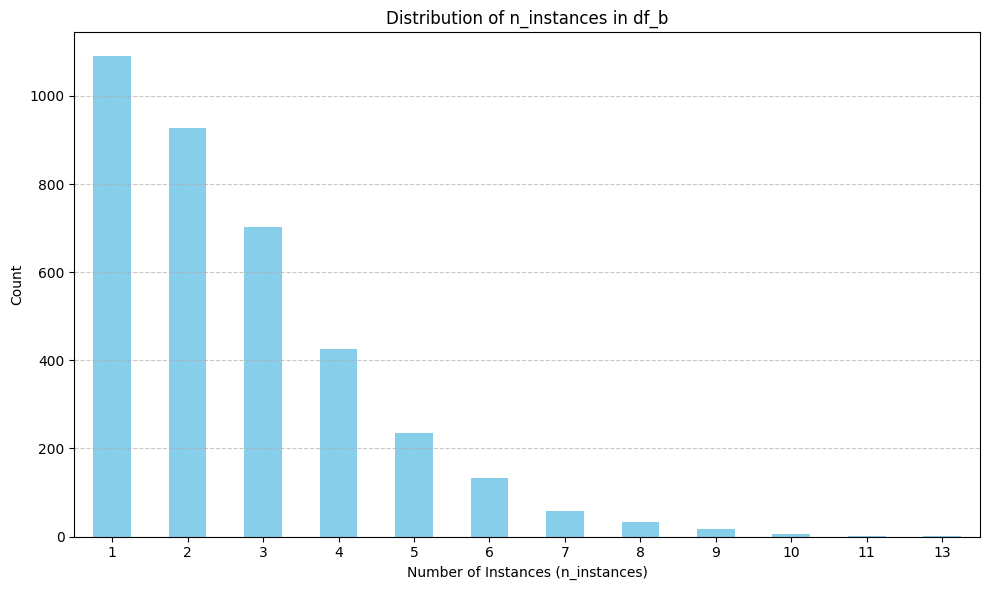

In [6]:
import matplotlib.pyplot as plt

# Calculate the count of each 'n_instances' value
instance_counts = df_b['n_instances'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
instance_counts.plot(kind='bar', color='skyblue')

# Add title and labels
plt.title('Distribution of n_instances in df_b')
plt.xlabel('Number of Instances (n_instances)')
plt.ylabel('Count')
plt.xticks(rotation=0) # Ensure x-axis labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [7]:
df_b1=df_b[df_b['n_instances']==1]
df_b1.shape

(1090, 33)

/tmp/ipython-input-1770967569.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b1['bed'] = df_b1['bed_date'].str.extract(r'(bed\d+)')[0]
/tmp/ipython-input-1770967569.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b1['date'] = df_b1['bed_date'].str.extract(r'_(\d{8})')[0]
/tmp/ipython-input-1770967569.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:


Total records: 1090
Date range: 2025-11-28 00:00:00 to 2025-12-26 00:00:00
Unique beds: 96

Filtered to top 10 beds: 136 records
  bed03: 9 records
  bed15: 13 records
  bed38: 16 records
  bed75: 12 records
  bed51: 11 records
  bed42: 14 records
  bed35: 12 records
  bed08: 17 records
  bed28: 13 records
  bed86: 19 records

Generating 3x4 individual time series plots...


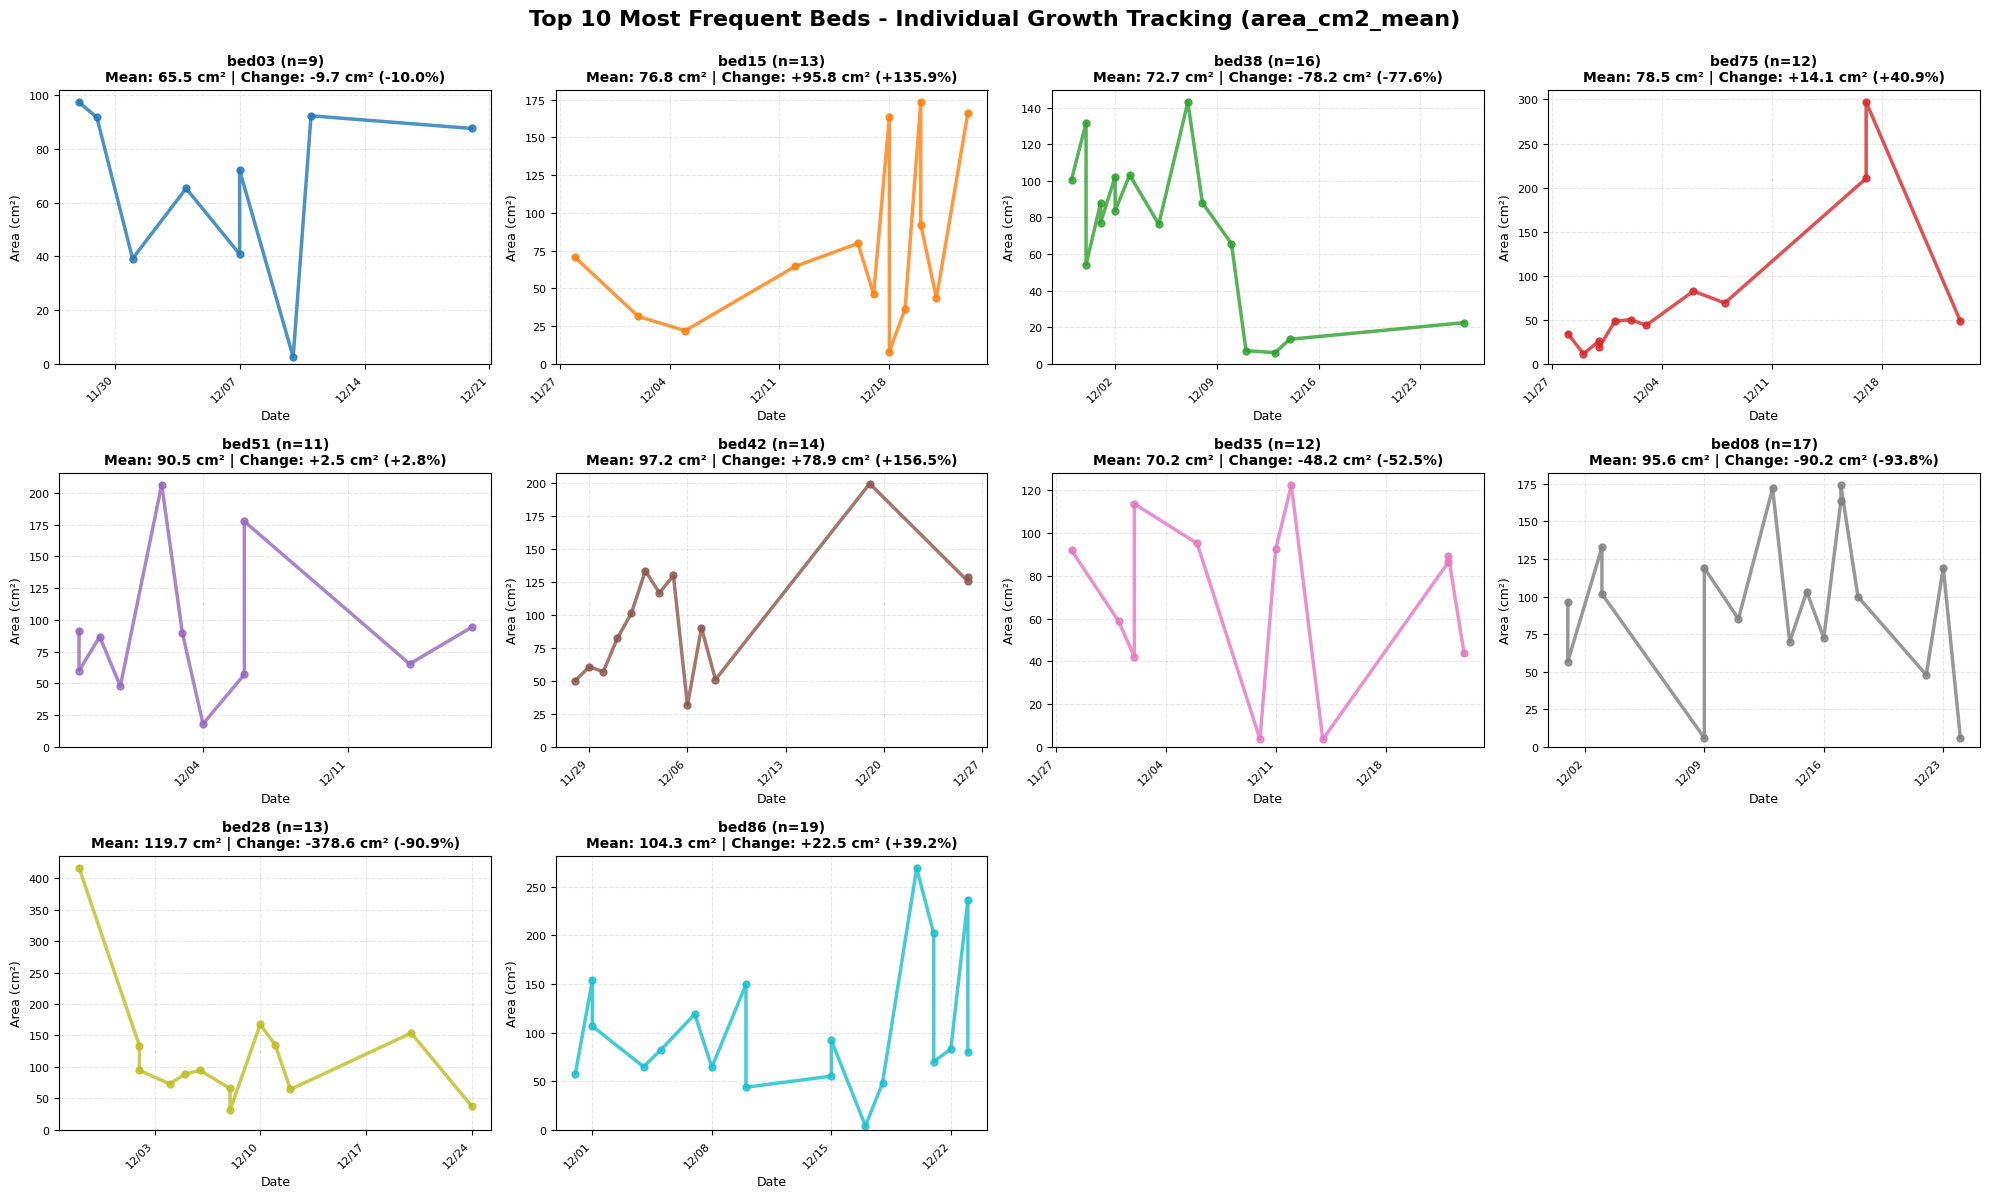

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Top 10 most frequently appearing beds (from first image)
TOP_10_BEDS = ['bed03', 'bed15', 'bed38', 'bed75', 'bed51', 'bed42', 'bed35', 'bed08', 'bed28', 'bed86']

# Extract bed number and date from bed_date column
df_b1['bed'] = df_b1['bed_date'].str.extract(r'(bed\d+)')[0]
df_b1['date'] = df_b1['bed_date'].str.extract(r'_(\d{8})')[0]
df_b1['date'] = pd.to_datetime(df_b1['date'], format='%Y%m%d')

print(f"\nTotal records: {len(df_b1)}")
print(f"Date range: {df_b1['date'].min()} to {df_b1['date'].max()}")
print(f"Unique beds: {df_b1['bed'].nunique()}")

# ============================================================================
# Filter Top 10 Beds
# ============================================================================
df_top10 = df_b1[df_b1['bed'].isin(TOP_10_BEDS)].copy()
df_top10 = df_top10.sort_values(['bed', 'date'])

print(f"\nFiltered to top 10 beds: {len(df_top10)} records")

# Check data availability for each bed
for bed in TOP_10_BEDS:
    bed_data = df_top10[df_top10['bed'] == bed]
    print(f"  {bed}: {len(bed_data)} records")

# ============================================================================
# Plot Individual Time Series (3x4 grid)
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds - Individual Growth Tracking (area_cm2_mean)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['area_cm2'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['area_cm2'].iloc[0]
        end_area = bed_data['area_cm2'].iloc[-1]
        mean_area = bed_data['area_cm2'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})\nMean: {mean_area:.1f} cm² | Change: {change:+.1f} cm² ({change_pct:+.1f}%)',
                    fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Area (cm²)', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


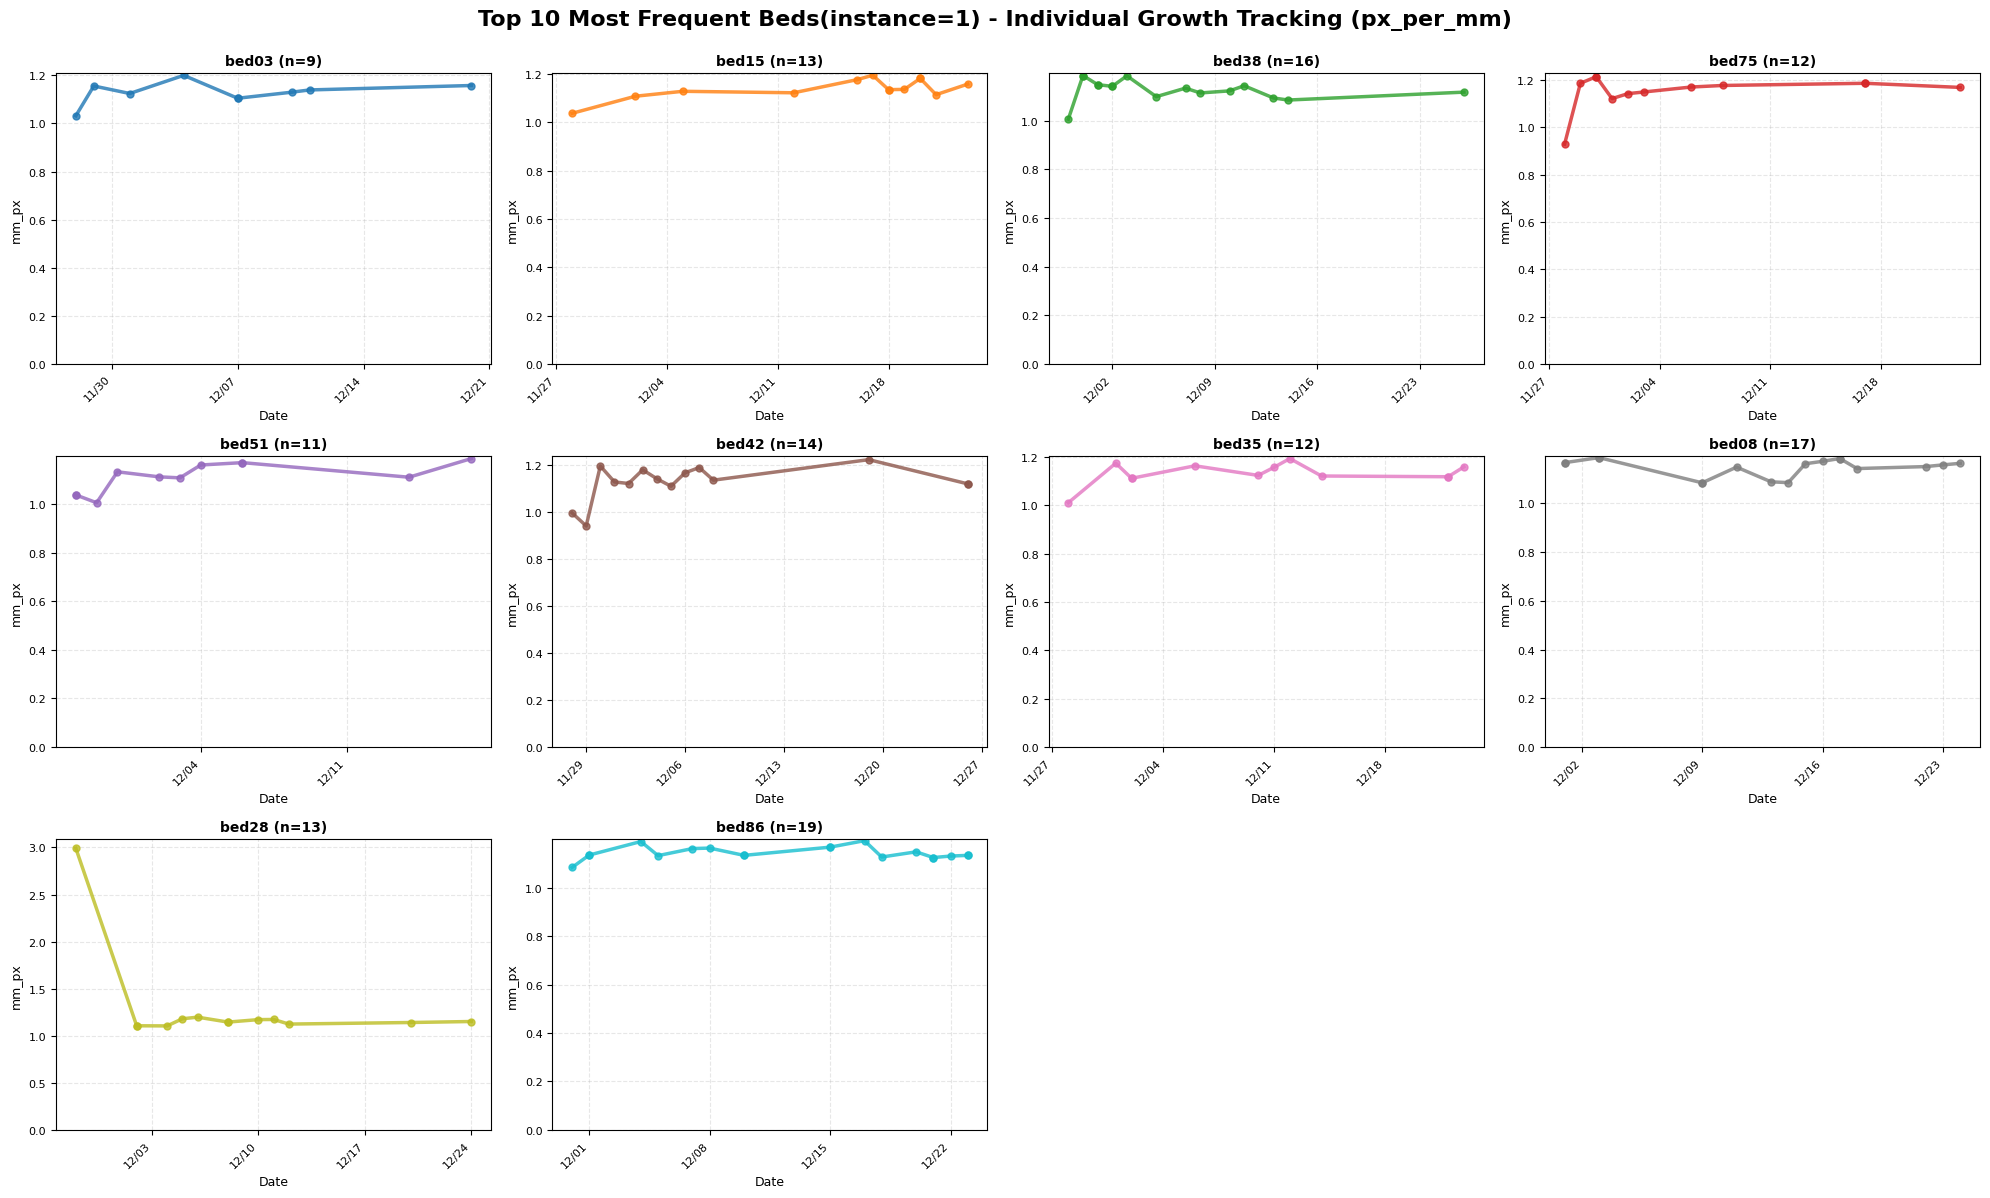

In [26]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (px_per_mm)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['mm_per_px'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['mm_per_px'].iloc[0]
        end_area = bed_data['mm_per_px'].iloc[-1]
        mean_area = bed_data['mm_per_px'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


In [4]:
df_b.columns

Index(['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
       'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
       'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
       'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
       'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
       'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
       'position_group', 'bed_date_clean', 'date', 'px_per_mm'],
      dtype='object')


Generating 3x4 individual time series plots...


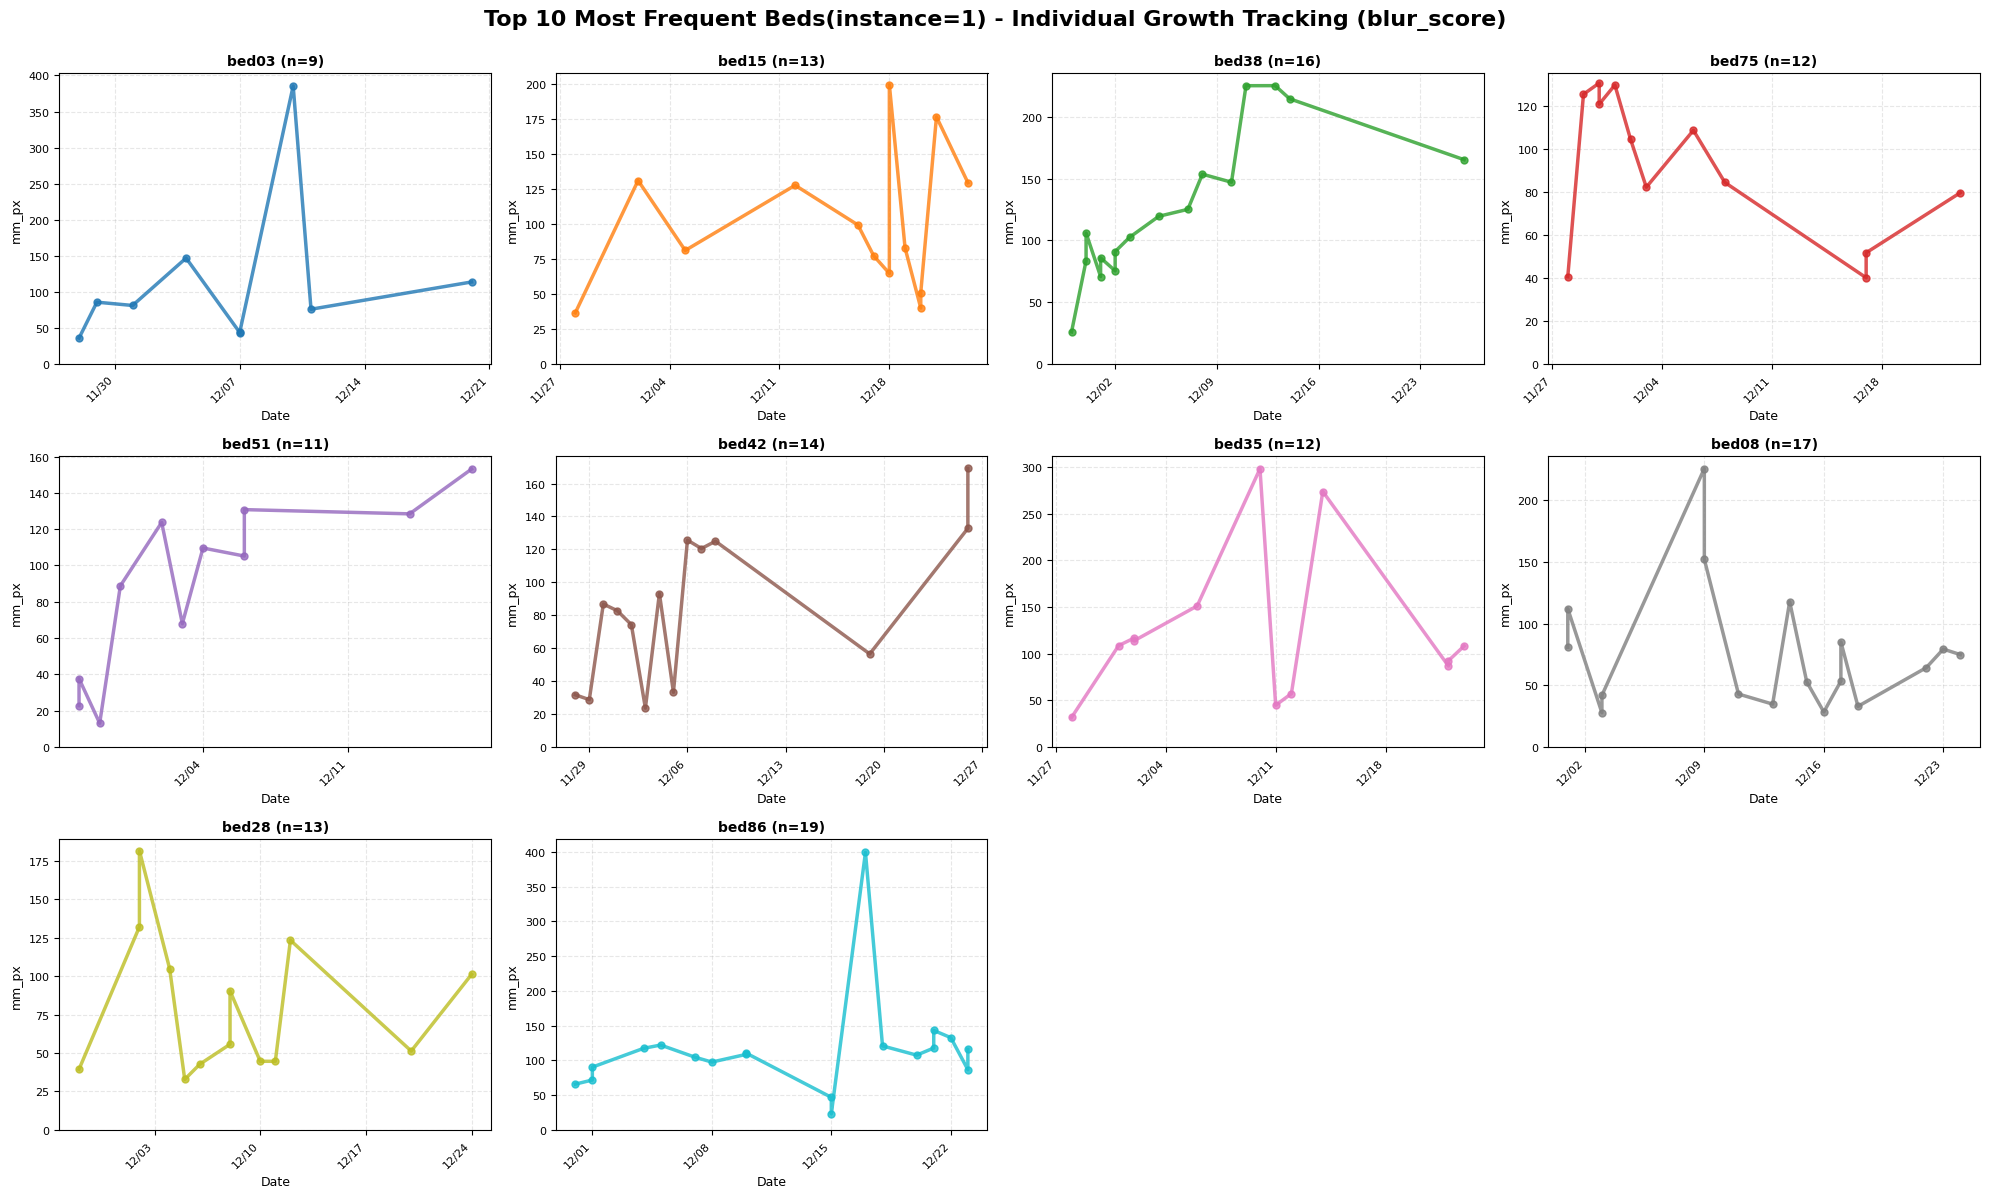

In [27]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (blur_score)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['blur_score'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['blur_score'].iloc[0]
        end_area = bed_data['blur_score'].iloc[-1]
        mean_area = bed_data['blur_score'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


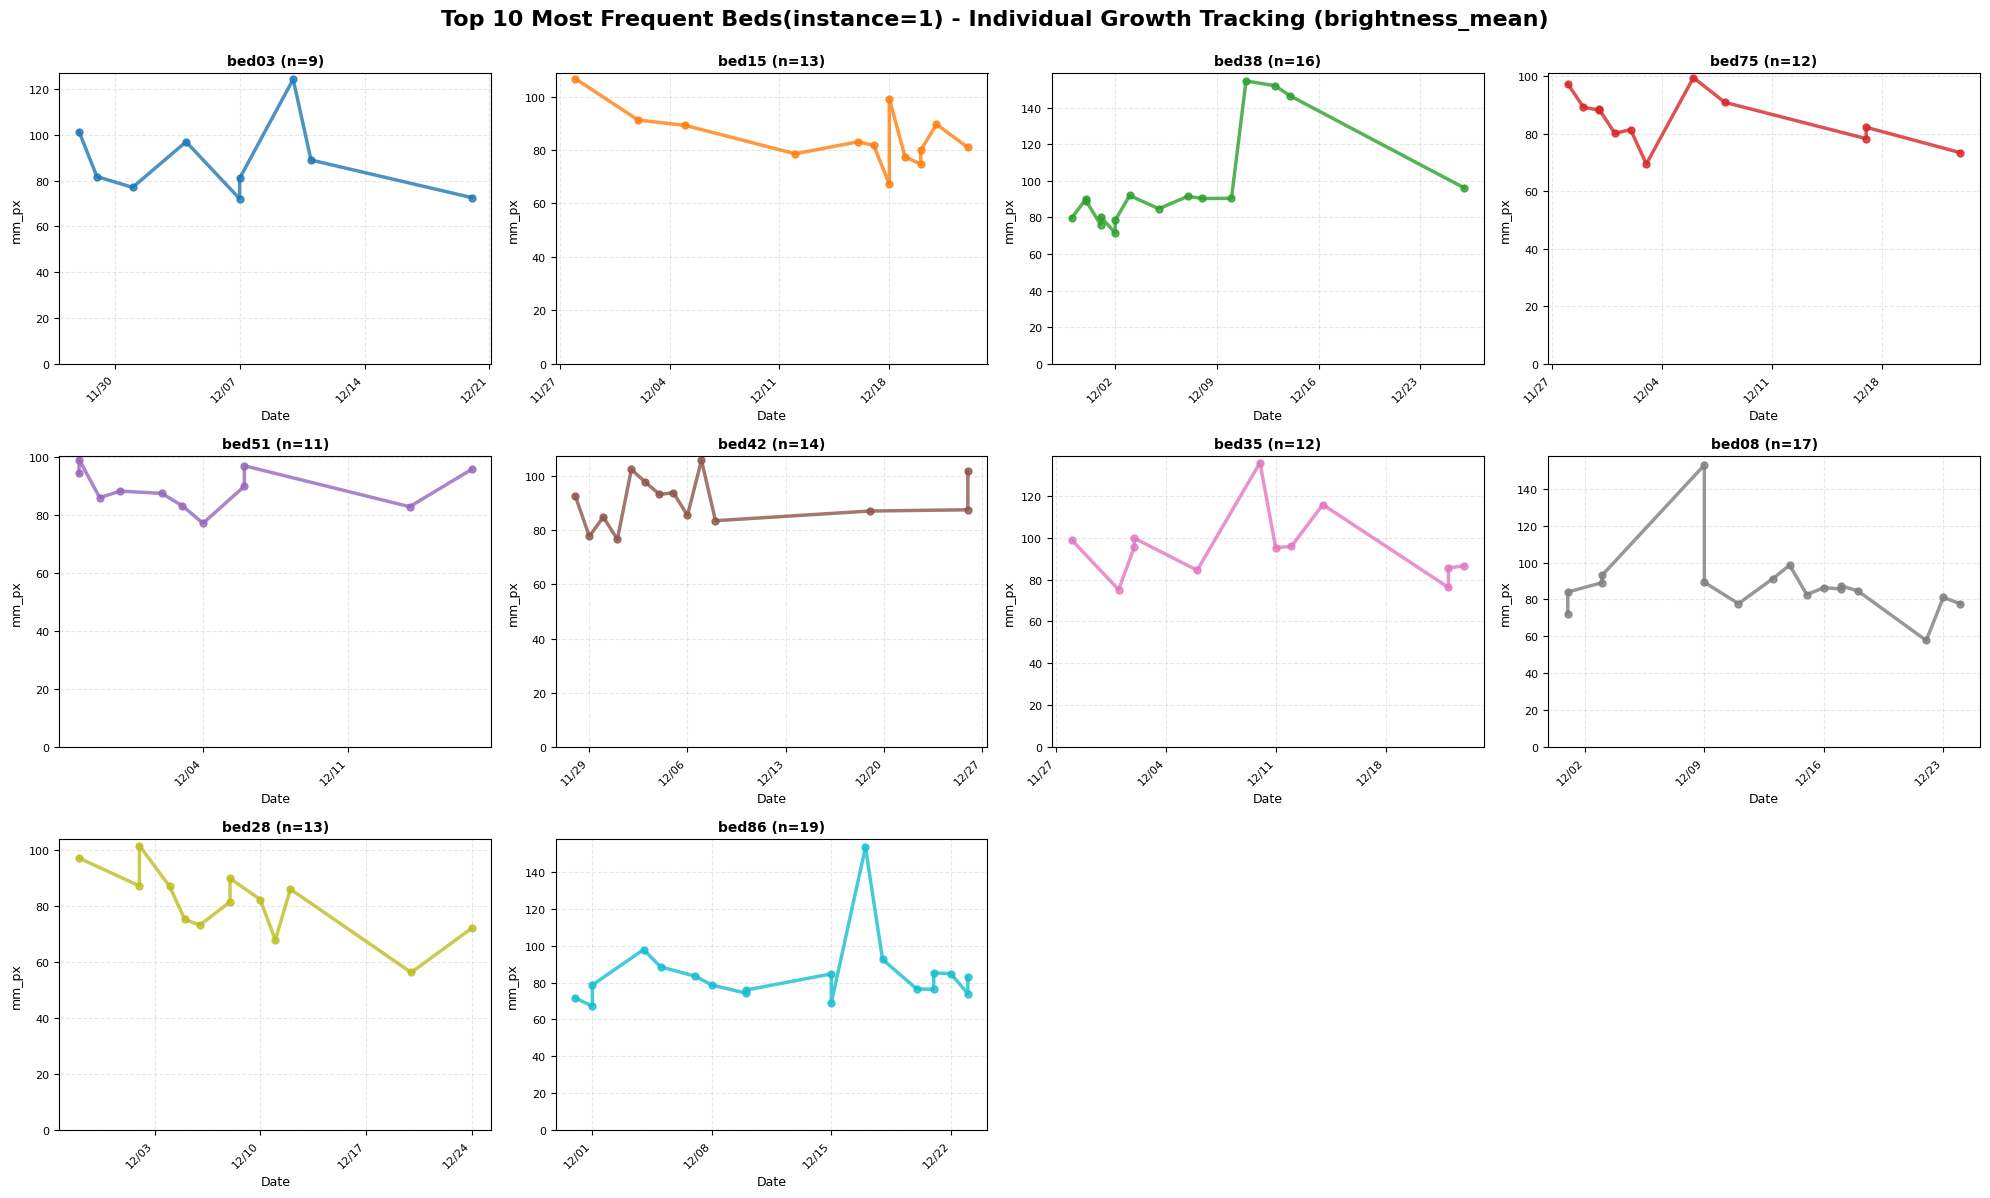

In [28]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (brightness_mean)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['brightness_mean'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['brightness_mean'].iloc[0]
        end_area = bed_data['brightness_mean'].iloc[-1]
        mean_area = bed_data['brightness_mean'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


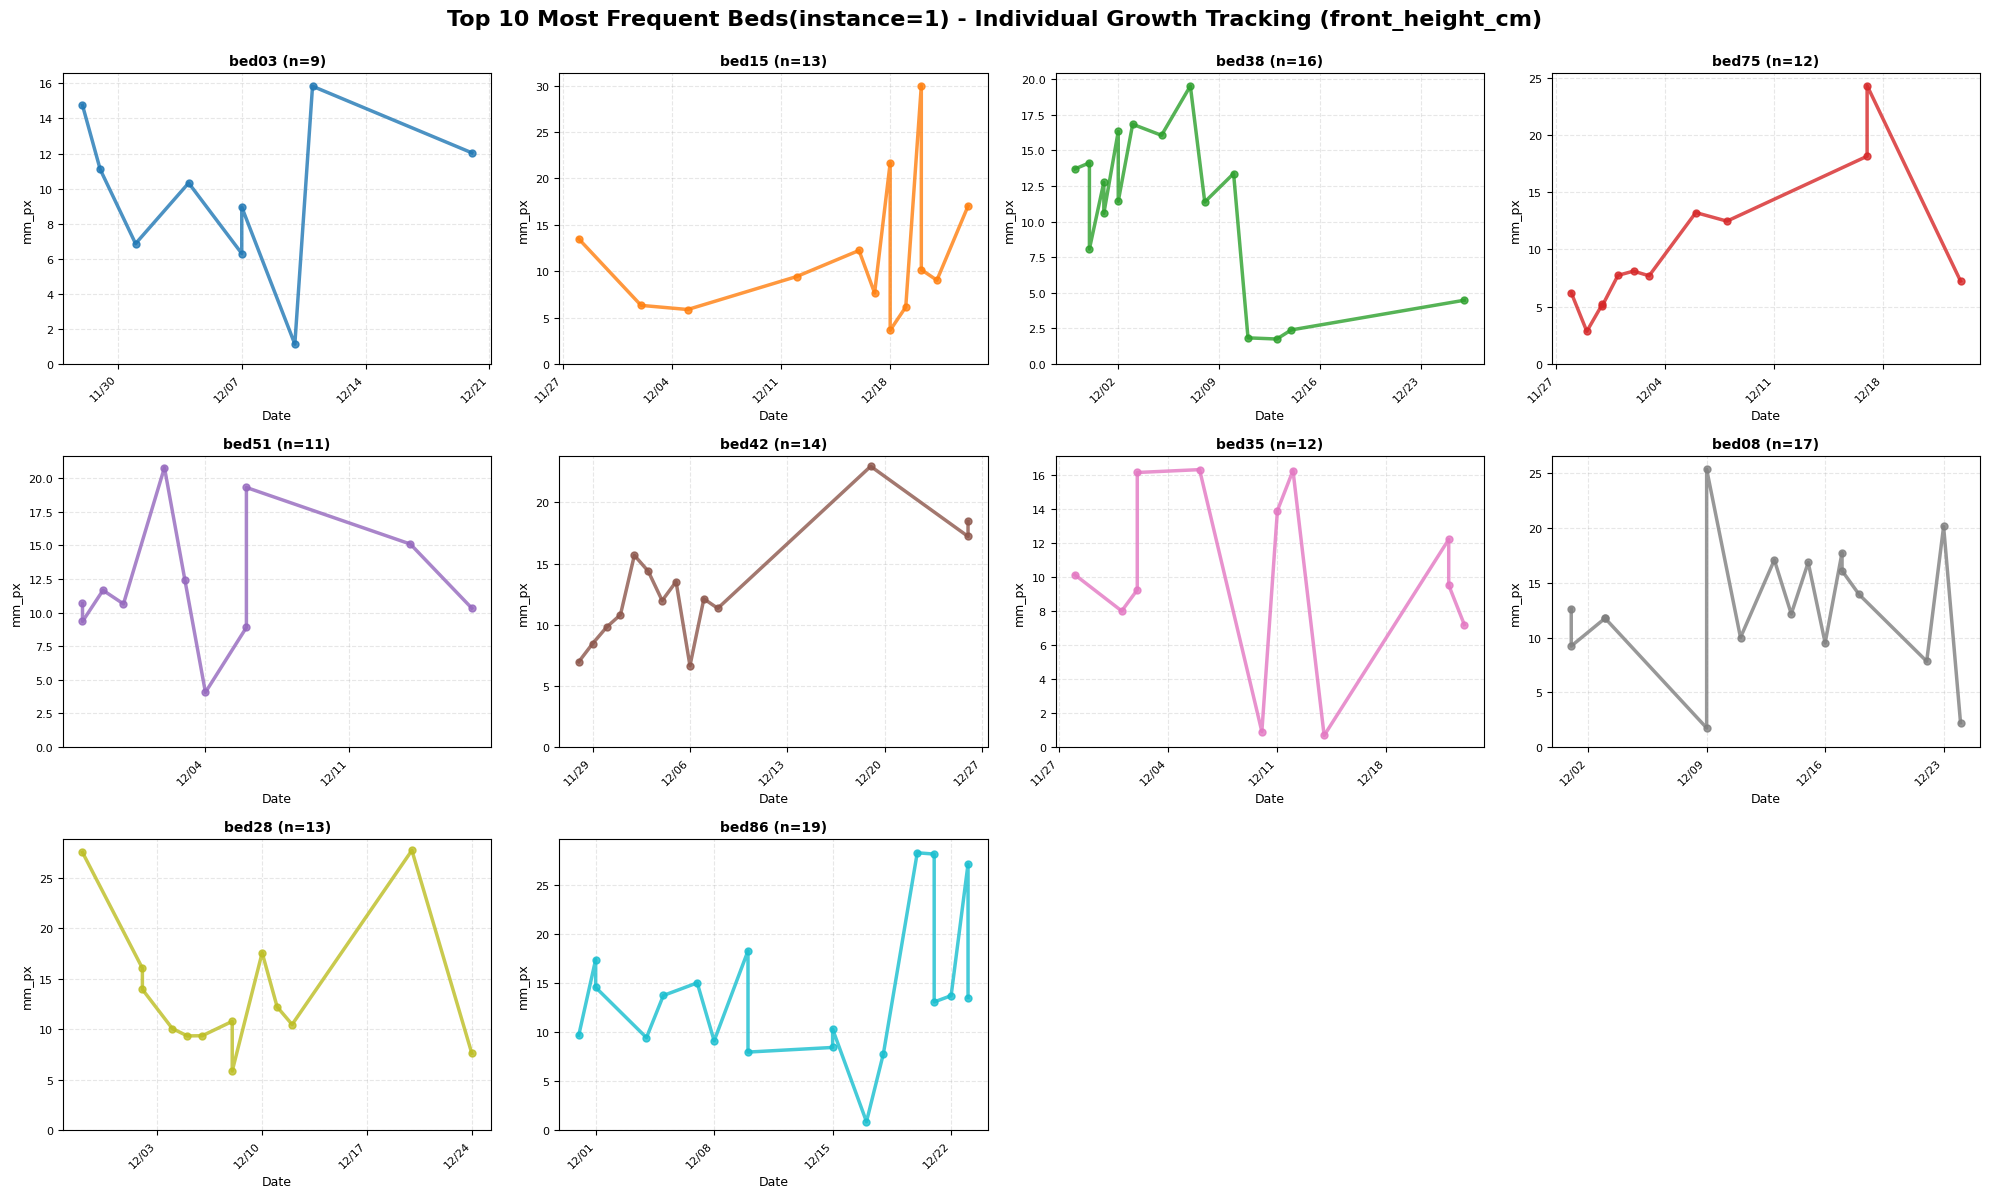

In [29]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (front_height_cm)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['front_height_cm'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['front_height_cm'].iloc[0]
        end_area = bed_data['front_height_cm'].iloc[-1]
        mean_area = bed_data['front_height_cm'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


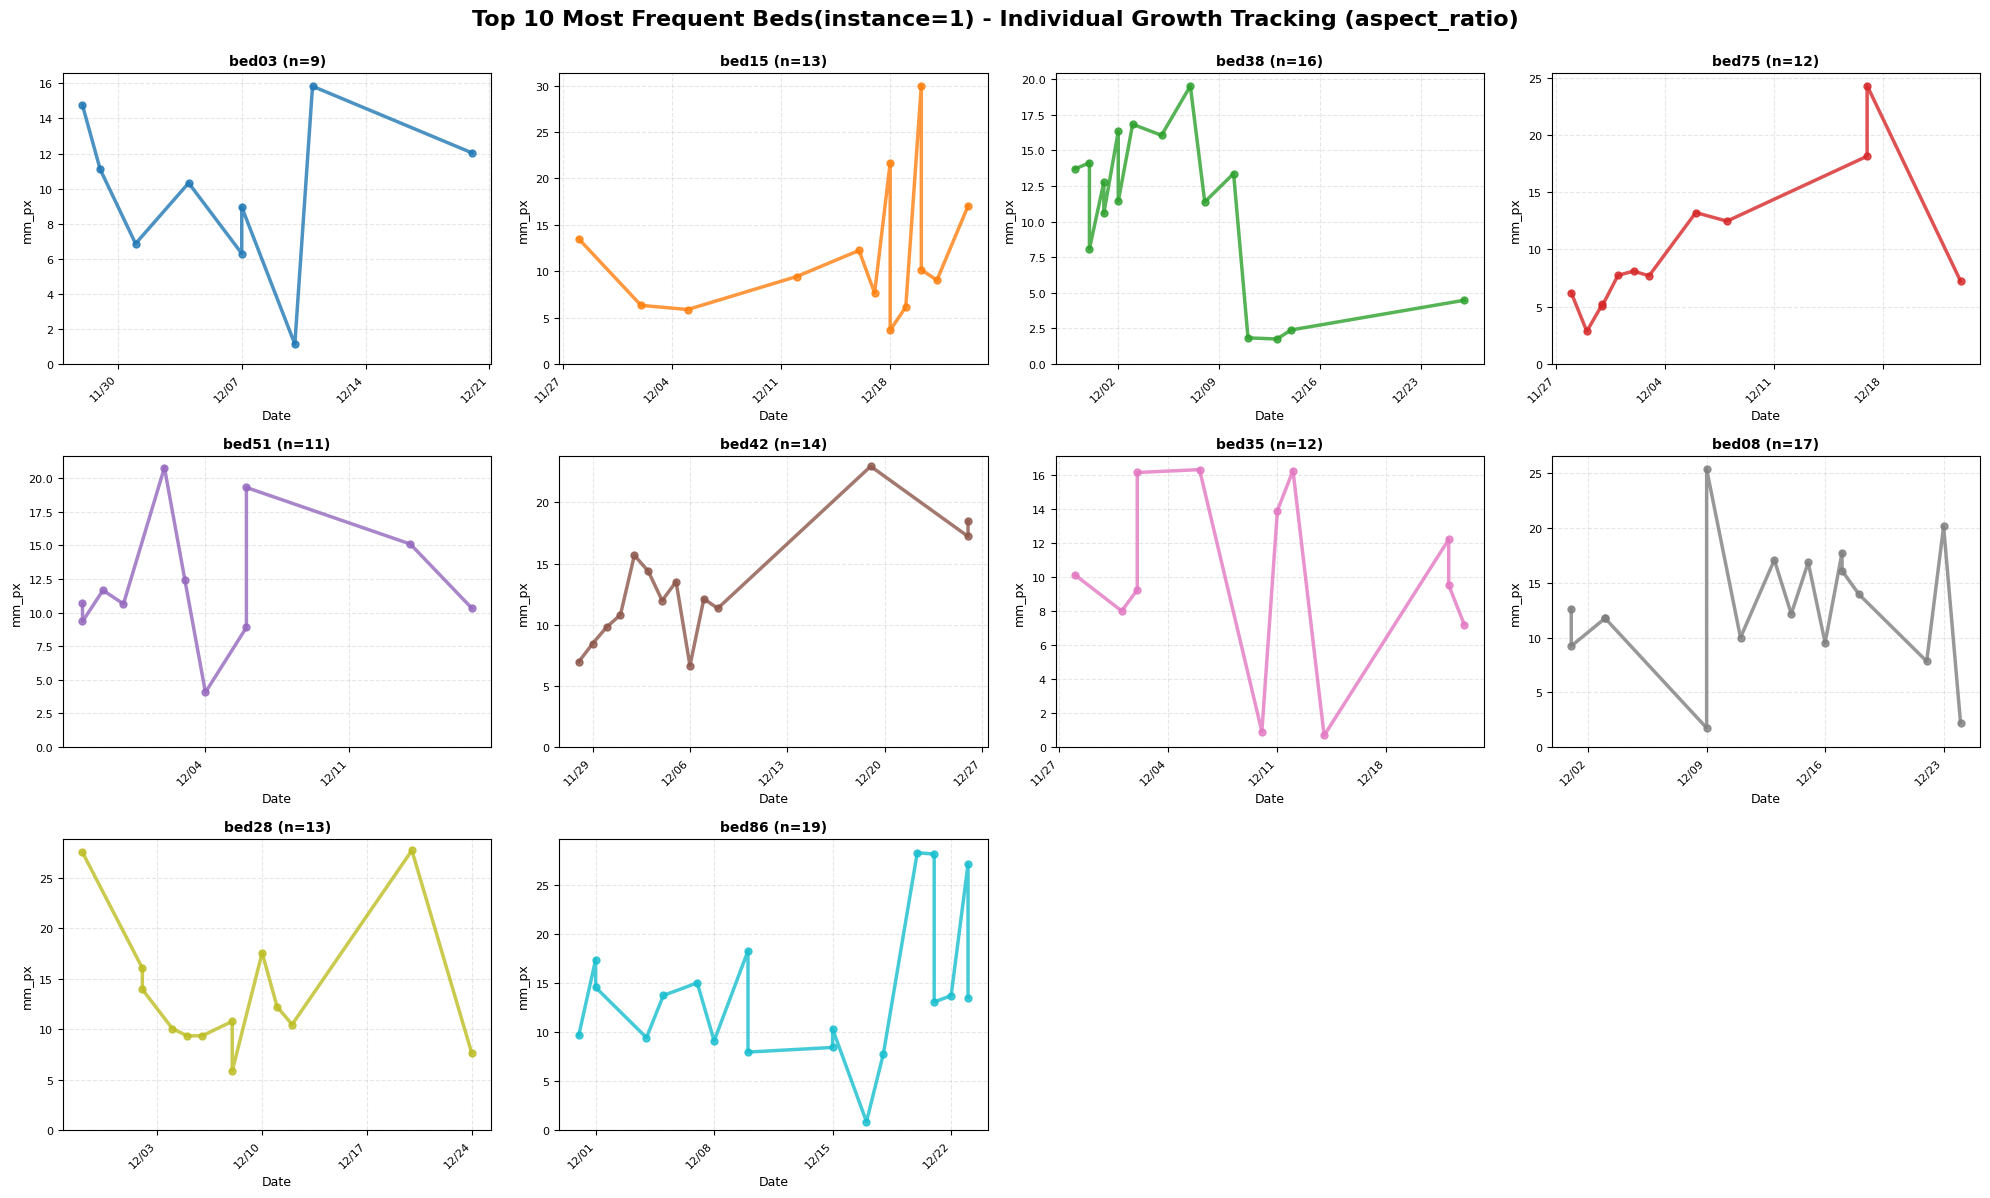

In [30]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (aspect_ratio)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['front_height_cm'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['aspect_ratio'].iloc[0]
        end_area = bed_data['aspect_ratio'].iloc[-1]
        mean_area = bed_data['aspect_ratio'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


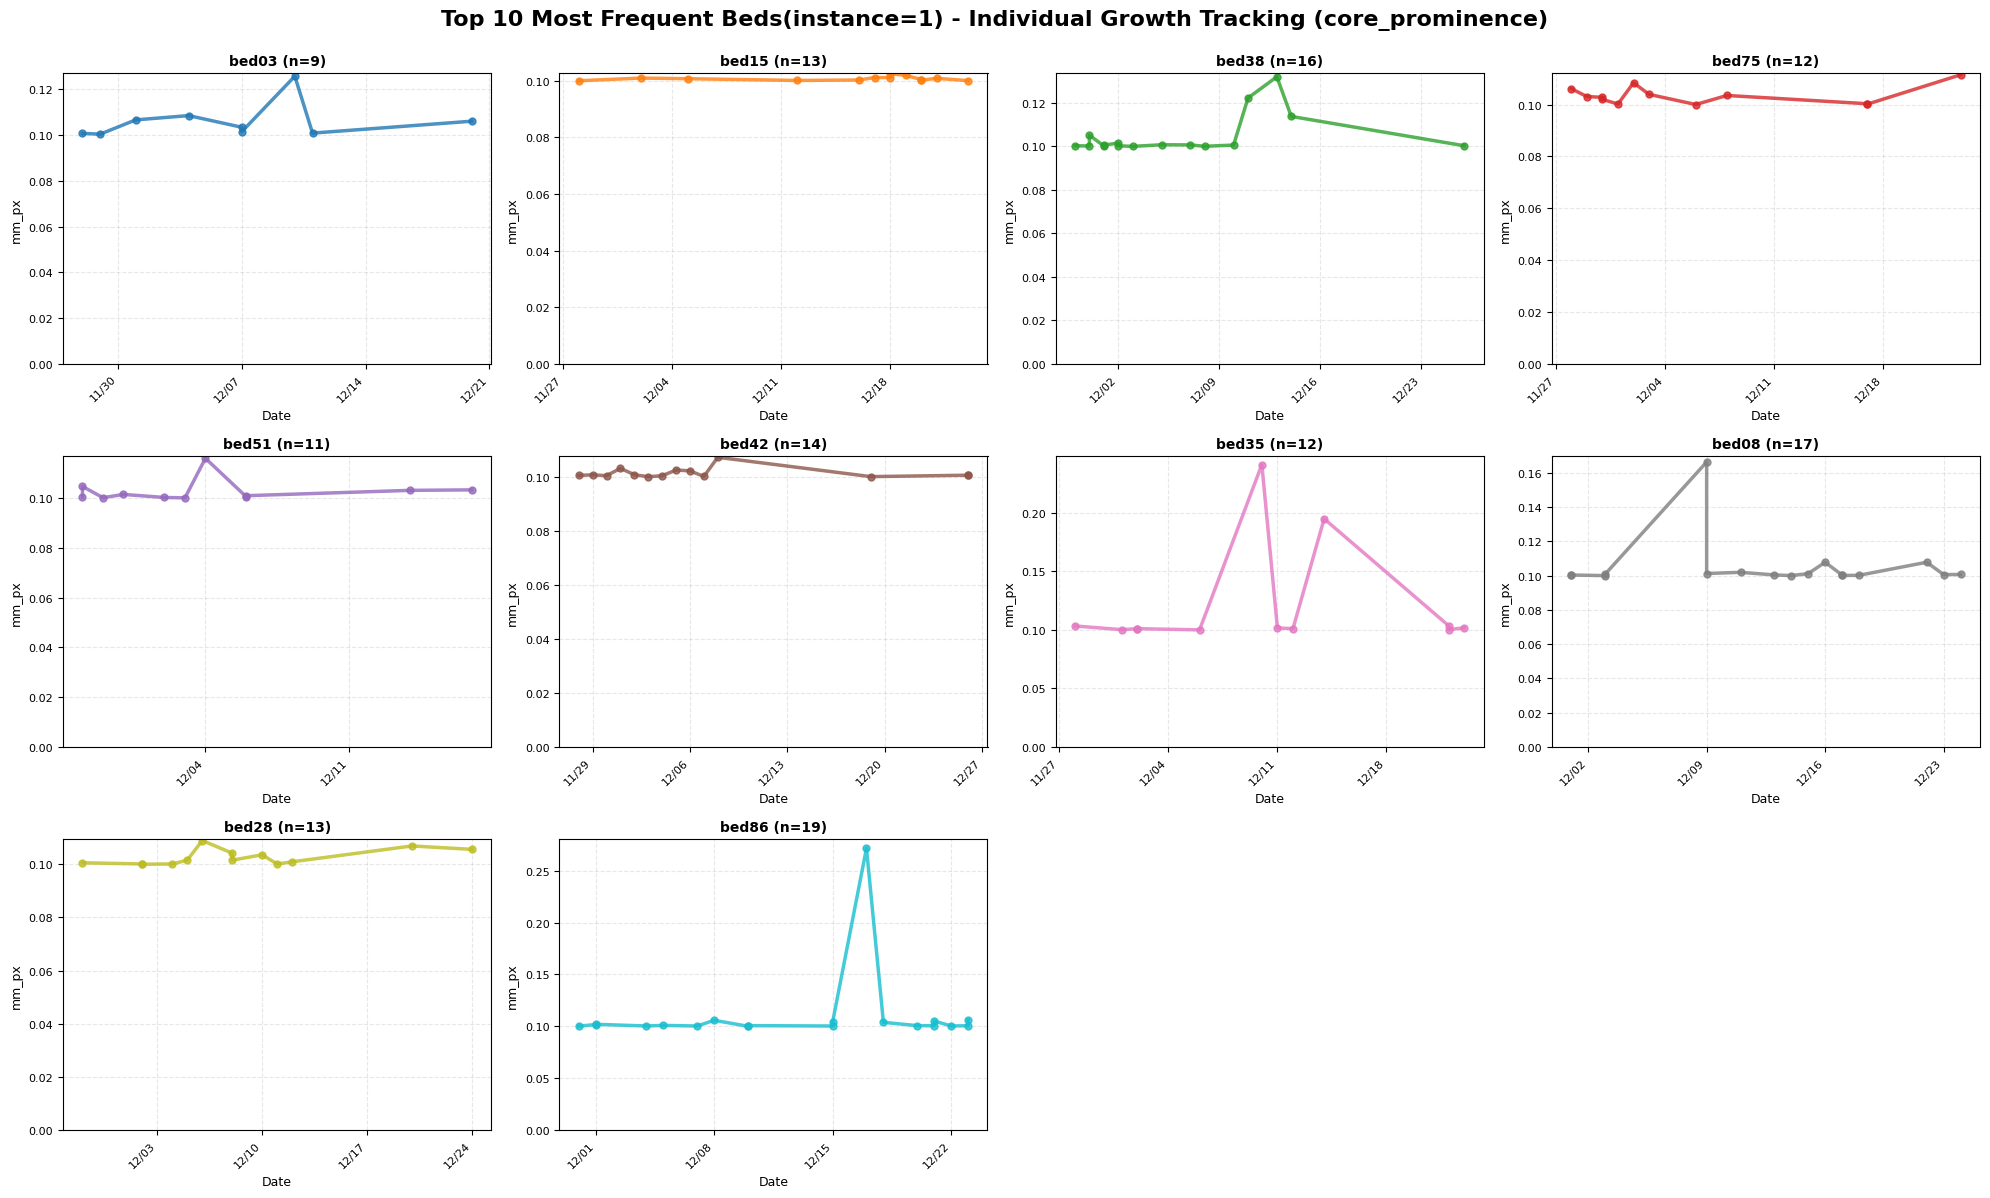

In [31]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (core_prominence)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['core_prominence'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['core_prominence'].iloc[0]
        end_area = bed_data['core_prominence'].iloc[-1]
        mean_area = bed_data['core_prominence'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()



Generating 3x4 individual time series plots...


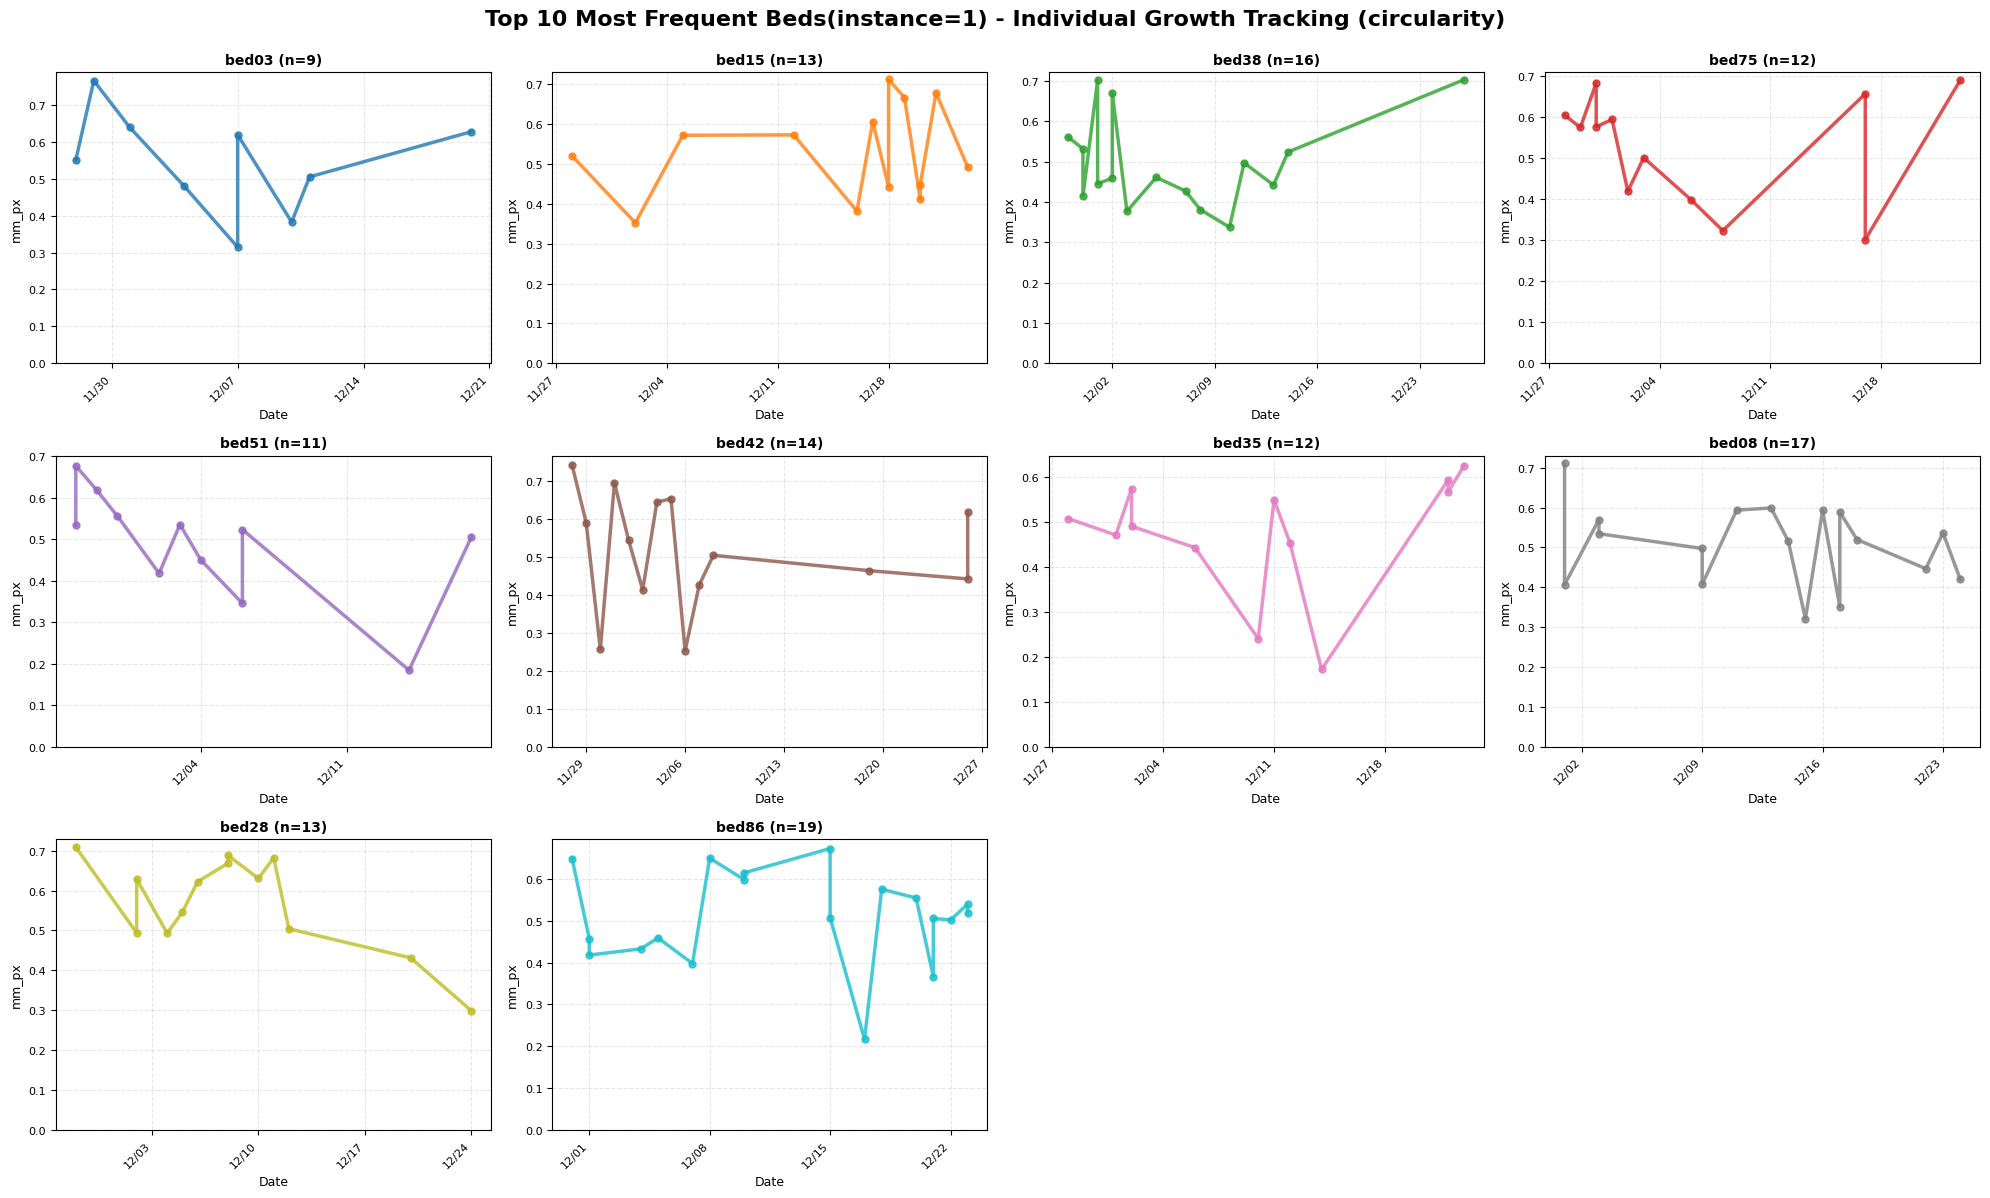

In [32]:
# ============================================================================
# Plot Individual Time Series (3x4 grid) : px_per_mm_x
# ============================================================================
print("\n" + "=" * 80)
print("Generating 3x4 individual time series plots...")
print("=" * 80)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Top 10 Most Frequent Beds(instance=1) - Individual Growth Tracking (circularity)',
             fontsize=16, fontweight='bold', y=0.995)

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Define colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, bed in enumerate(TOP_10_BEDS):
    ax = axes_flat[idx]

    # Get data for this bed
    bed_data = df_top10[df_top10['bed'] == bed].sort_values('date')

    if len(bed_data) > 0:
        # Plot line graph
        ax.plot(bed_data['date'], bed_data['circularity'],
               color=colors[idx], linewidth=2.5, marker='o', markersize=5,
               label=bed, alpha=0.8)

        # Calculate statistics
        start_area = bed_data['circularity'].iloc[0]
        end_area = bed_data['circularity'].iloc[-1]
        mean_area = bed_data['circularity'].mean()
        change = end_area - start_area
        change_pct = (change / start_area * 100) if start_area > 0 else 0

        # Title with statistics
        ax.set_title(f'{bed} (n={len(bed_data)})', fontsize=10, fontweight='bold')

        # Labels
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_px', fontsize=9)

        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')

        # X-axis format
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

        # Y-axis format
        ax.tick_params(axis='y', labelsize=8)

        # Set y-axis to start from 0 for better comparison
        ax.set_ylim(bottom=0)

    else:
        ax.text(0.5, 0.5, f'{bed}\nNo data available',
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('mm_x', fontsize=9)

# Hide extra subplots (we have 10 beds, so 2 empty panels in 3x4 grid)
for idx in range(len(TOP_10_BEDS), 12):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
df_b.columns

Index(['image_path', 'base_key', 'lettuce_id', 'bed_date', 'n_instances',
       'conf', 'brightness_mean', 'blur_score', 'area_px', 'area_cm2',
       'px_per_mm_x', 'px_per_mm_y', 'mm_per_px', 'cyl_ok', 'cyl_diam_px',
       'front_height_cm', 'area_front', 'aspect_ratio', 'bottom_flatness',
       'core_prominence', 'bbox_w', 'bbox_h', 'perimeter_px', 'circularity',
       'solidity', 'concavity', 'curvature', 'roughness', 'best_instance',
       'position_group', 'bed_date_clean', 'date', 'px_per_mm'],
      dtype='object')